In [27]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import matplotlib
import numpy as np

In [2]:
# the goal of this notbeook is collapse TF matches to a single call and count top motifs for each cell type
# the merged bed files loaded here were generated by 'mpac_promoter_seqlet_bedmap_merge.sh'
# the 'rules' are as follows:
# 1. single intervals are unchanged
# 2. merged intervals that have the same TF call are just called that TF
# 3. merged intervals that have multiple TF calls will be called the TF with the highest absolute attribution in the interval

In [3]:
# 9:55PM 092125 - for now we will write all the code for the no-overlap bed file but we'll make it a function so you can plug and chug for comparisons
# open K562 no min overlap bed file
k562_merged_bed_noMin = pd.read_csv('../processed_data/bed_files/K562_bedOps_merged_noMin_seqlets_01_112225.bed', sep = '\t', header = None)
# hepg2 no min overlap bed file
hepg2_merged_bed_noMin = pd.read_csv('../processed_data/bed_files/HepG2_bedOps_merged_noMin_seqlets_01_112225.bed', sep = '\t', header = None)
# sknsh no min overlap bed file
sknsh_merged_bed_noMin = pd.read_csv('../processed_data/bed_files/SKNSH_bedOps_merged_noMin_seqlets_01_112225.bed', sep = '\t', header = None)

In [4]:
# open PARM no min overlap bed files
# k562
k562_parm_merged_noMin = pd.read_csv('../processed_data/bed_files/PARM_K562_sig_TFs_bedOps_merged_noMin_112225.bed', sep = '\t', header = None)
# hepg2
hepg2_parm_merged_noMin = pd.read_csv('../processed_data/bed_files/PARM_HepG2_sig_TFs_bedOps_merged_noMin_112225.bed', sep = '\t', header = None)

In [5]:
def assign_representative_tf(bed_file):
    """
    Reads a mapped BED file, assigns a single representative TF, and
    classifies its activity based on attribution score.

    Args:
        bed_file (pd.DataFrame): DataFrame from the bedmap output.

    Returns:
        pd.DataFrame: The original DataFrame with two new columns:
                      'representative_tf' and 'activity_class'.
    """
    df = bed_file
    data_column_index = 3

    representative_tfs = []
    activity_classes = [] # New list to store the activity class
    attributions = []
    for index, row in df.iterrows():
        mapped_info_string = str(row[data_column_index])
        tf_hits = mapped_info_string.split(';')
        
        best_tf = ''
        best_score = 0.0 # Variable to hold the signed score of the winner
        
        if len(tf_hits) == 1:
            # RULE 1: Only one TF is present
            parts = tf_hits[0].split('_')
            best_tf = ('_').join(parts[:2])
            try:
                best_score = float(parts[-1])
            except (ValueError, IndexError):
                best_score = 0.0 # Default if score is missing
        else:
            # RULES 2 & 3: Multiple TFs are present
            max_abs_attribution = -1.0
            all_tf_names = set()
            
            for hit in tf_hits:
                parts = hit.split('_')
                tf_name = ('_').join(parts[:2])
                all_tf_names.add(tf_name)
                
                try:
                    attribution_score = float(parts[-1])
                    if abs(attribution_score) > max_abs_attribution:
                        max_abs_attribution = abs(attribution_score)
                        best_tf = tf_name
                        best_score = attribution_score # Store the signed score
                except (ValueError, IndexError):
                    continue
            
            if len(all_tf_names) == 1:
                # RULE 2: Motifs are the same, just use the single name
                best_tf = list(all_tf_names)[0]

        # Append the chosen TF and determine its class
        representative_tfs.append(best_tf)
        
        if best_score > 0:
            activity_classes.append('Activator')
            attributions.append(best_score)
        elif best_score < 0:
            activity_classes.append('Repressor')
            attributions.append(best_score)
        else:
            activity_classes.append('Neutral') # For scores of 0 or errors
            attributions.append(best_score)

    # Add the two new columns to the DataFrame
    df['representative_tf'] = representative_tfs
    df['activity_class'] = activity_classes
    df['attribution'] = attributions
    
    return df

In [6]:
# collapse TFs for each cell type - MPAC
# k562
k562_noMin_collapsed = assign_representative_tf(k562_merged_bed_noMin)
# hepg2
hepg2_noMin_collapsed = assign_representative_tf(hepg2_merged_bed_noMin)
# sknsh
sknsh_noMin_collapsed = assign_representative_tf(sknsh_merged_bed_noMin)

In [7]:
k562_noMin_collapsed.to_csv('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed', sep = '\t', index = False, header = None)
hepg2_noMin_collapsed.to_csv('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed', sep = '\t', index = False, header = None)
sknsh_noMin_collapsed.to_csv('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed', sep = '\t', index = False, header = None)

In [10]:
# open the DF of full 250bp promoters
fullPromoters = pd.read_csv('../processed_data/complete.merged.250bp.promoters.exon.filtered.tsv', sep = '\t')['promoter_id'].tolist()

In [8]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [32]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed (path2bed,
                    promoterList,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activity_class' : filtered_bed[5]})
    return bed2plot

In [58]:
k_vierstra_collapsed = mpac_collapsed('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed',
                        fullPromoters,
                        vierstra_motif_dict)
h_vierstra_collapsed = mpac_collapsed('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed',
                        fullPromoters,
                        vierstra_motif_dict)
s_vierstra_collapsed = mpac_collapsed('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed',
                        fullPromoters,
                        vierstra_motif_dict)


In [35]:
def plot_multicell_tf_panels(
    dfs: dict,  # {'K562': df1, 'HepG2': df2, 'SKNSH': df3}
    cell_colors: dict,  # {'K562': '#17becf', 'HepG2': '#f4a742', 'SKNSH': '#e74c3c'}
    output_path: str = None,
    top_n: int = 10,
    activity_type: str = 'Activator',  # 'Activator' or 'Repressor'
    plot_type: str = 'percentages'
):
    """
    Creates a multi-panel figure with one subplot per cell type,
    each showing its own top N TFs.
    
    Args:
        dfs: Dictionary mapping cell type names to DataFrames.
              Each DataFrame needs 'tf_family' and 'activity_class' columns.
        cell_colors: Dictionary mapping cell type names to colors.
        output_path: Path to save the plot (optional).
        top_n: Number of top TFs to display per cell type.
        activity_type: 'Activator' or 'Repressor'.
        plot_type: 'counts' or 'percentages'.
    """
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    cell_types = list(dfs.keys())
    n_cells = len(cell_types)
    
    # Create figure with subplots (one column per cell type)
    fig, axes = plt.subplots(1, n_cells, figsize=(3,2))
    
    # Handle single cell type case
    if n_cells == 1:
        axes = [axes]
    
    # Find global max for consistent x-axis across panels
    global_max = 0
    panel_data = {}
    
    for cell_type, df in dfs.items():
        subset = df[df['activity_class'] == activity_type]
        counts = subset['tf_family'].value_counts().head(top_n)
        
        if plot_type == 'percentages':
            total = len(subset)
            values = (counts / total * 100) if total > 0 else counts
        else:
            values = counts
        
        panel_data[cell_type] = values
        if len(values) > 0:
            global_max = max(global_max, values.max())
    
    x_label = '% Total Calls' if plot_type == 'percentages' else 'Count'
    
    # Plot each panel
    for ax, cell_type in zip(axes, cell_types):
        values = panel_data[cell_type]
        tfs = values.index.tolist()[::-1]  # Reverse so highest at top
        vals = values.values[::-1]
        
        y_pos = np.arange(len(tfs))
        
        ax.barh(y_pos, vals, color=cell_colors[cell_type], edgecolor='white', linewidth=0.5)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(tfs, fontsize=4)
        ax.set_xlabel(x_label, fontsize=4)
        ax.tick_params(axis='x', labelsize=4)
        ax.set_xlim(0, global_max * 1.1)  # Consistent x-axis
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if output_path:
        #plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {output_path}")
    
    return fig, axes, vals

In [48]:
def assign_representative_tf_parm(bed_file):
    """
    Reads a mapped BED file, assigns a single representative TF, and
    classifies its activity based on attribution score.

    Args:
        bed_file (pd.DataFrame): DataFrame from the bedmap output.

    Returns:
        pd.DataFrame: The original DataFrame with two new columns:
                      'representative_tf' and 'activity_class'.
    """
    df = bed_file
    data_column_index = 3

    representative_tfs = []
    activity_classes = [] # New list to store the activity class
    attributions = []
    for index, row in df.iterrows():
        mapped_info_string = str(row[data_column_index])
        tf_hits = mapped_info_string.split(';')
        
        best_tf = ''
        best_score = 0.0 # Variable to hold the signed score of the winner
        
        if len(tf_hits) == 1:
            # RULE 1: Only one TF is present
            parts = tf_hits[0].split(':')
            best_tf = parts[0].split('-')[0]
            try:
                best_score = float(parts[1])
            except (ValueError, IndexError):
                best_score = 0.0 # Default if score is missing
        else:
            # RULES 2 & 3: Multiple TFs are present
            max_abs_attribution = -1.0
            all_tf_names = set()
            
            for hit in tf_hits:
                parts = hit.split(':')
                tf_name = parts[0].split('-')[0]
                all_tf_names.add(tf_name)
                
                try:
                    attribution_score = float(parts[1])
                    if abs(attribution_score) > max_abs_attribution:
                        max_abs_attribution = abs(attribution_score)
                        best_tf = tf_name
                        best_score = attribution_score # Store the signed score
                except (ValueError, IndexError):
                    continue
            
            if len(all_tf_names) == 1:
                # RULE 2: Motifs are the same, just use the single name
                best_tf = list(all_tf_names)[0]

        # Append the chosen TF and determine its class
        representative_tfs.append(best_tf)
        
        if best_score > 0:
            activity_classes.append('Activator')
            attributions.append(best_score)
        elif best_score < 0:
            activity_classes.append('Repressor')
            attributions.append(best_score)
        else:
            activity_classes.append('Neutral') # For scores of 0 or errors
            attributions.append(best_score)

    # Add the two new columns to the DataFrame
    df['representative_tf'] = representative_tfs
    
    df['activity_class'] = activity_classes
    df['attribution'] = attributions
    
    return df

Plot saved to: x


(<Figure size 300x200 with 3 Axes>,
 array([<Axes: xlabel='% Total Calls'>, <Axes: xlabel='% Total Calls'>,
        <Axes: xlabel='% Total Calls'>], dtype=object),
 array([ 0.5904582 ,  0.63769485,  0.75578649,  0.82664147,  0.8502598 ,
         0.92111479,  0.94473311,  0.99196977,  1.65328295,  2.66887104,
         2.81058101,  3.49551252,  3.7316958 ,  3.92064242,  5.62116202,
         5.76287199,  6.47142182,  6.84931507, 13.08455361, 31.62494095]))

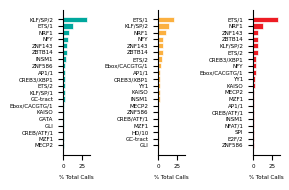

In [63]:
plot_multicell_tf_panels(
    dfs={
        'K562' : k_vierstra_collapsed,
        'HepG2' : h_vierstra_collapsed,
        'SKNSH' : s_vierstra_collapsed
    },
    cell_colors={
        'K562' : '#00A79D',
        'HepG2' : '#FBB040',
        'SKNSH' : '#ED1C24'
    },
    top_n=20,
    activity_type='Activator',
    plot_type='percentages',
    output_path='x'
)

Plot saved to: x


(<Figure size 300x200 with 3 Axes>,
 array([<Axes: xlabel='% Total Calls'>, <Axes: xlabel='% Total Calls'>,
        <Axes: xlabel='% Total Calls'>], dtype=object),
 array([ 0.89055543,  1.12491212,  2.60135927,  2.76540895,  2.95289431,
         3.53878603,  3.74970705,  4.07780642,  5.81204593, 54.79259433]))

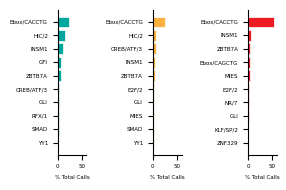

In [61]:
plot_multicell_tf_panels(
    dfs={
        'K562' : k_vierstra_collapsed,
        'HepG2' : h_vierstra_collapsed,
        'SKNSH' : s_vierstra_collapsed
    },
    cell_colors={
        'K562' : '#00A79D',
        'HepG2' : '#FBB040',
        'SKNSH' : '#ED1C24'
    },
    top_n=10,
    activity_type='Repressor',
    plot_type='percentages',
    output_path='x'
)

Plot saved to: x


(<Figure size 300x200 with 1 Axes>,
 [<Axes: xlabel='% Total Calls'>],
 array([ 2.44747672,  2.4691358 ,  2.51245397,  2.57743123,  2.81568118,
         3.76868096,  5.34979424,  8.70695257, 13.77517869, 24.14988088]))

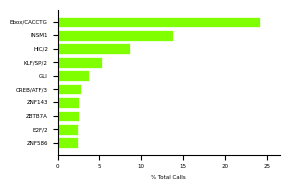

In [65]:
plot_multicell_tf_panels(
    dfs={
        'K562' : k_parmTangermeme_collapsed,
        #'HepG2' : h_mpac_collapsed_dels,
        #'SKNSH' : s_mpac_collapsed_dels
    },
    cell_colors={
        'K562' : 'chartreuse',
        'HepG2' : '#FBB040',
        'SKNSH' : '#ED1C24'
    },
    top_n=10,
    activity_type='Repressor',
    plot_type='percentages',
    output_path='x'
)

In [44]:
# define function for reformatting parm TANGERMEME tf calls - collapsed
def parmTangermeme_collapsed (path2bed,
                              promoterList,
                              motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene_ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activity_class' : filtered_bed[5]})
    return bed2plot

In [37]:
# collapse PARM TF match calls
# k562
k562_parmCall_merged = assign_representative_tf_parm(k562_parm_merged_noMin)
# hepg2
hepg2_parmCall_merged = assign_representative_tf_parm(hepg2_parm_merged_noMin)

In [38]:
k562_parmCall_merged.head()

,0,1,2,3,representative_tf,activity_class,attribution
0,chr1,65375,65385,TBP_HUMAN.H11MO.0.A:0.7657776106442673:ENSG000...,TBP_HUMAN.H11MO.0.A,Activator,0.765778
1,chr1,65391,65400,FOXH1_HUMAN.H11MO.0.A-:-0.77973251718781:ENSG0...,FOXH1_HUMAN.H11MO.0.A,Repressor,-0.779733
2,chr1,451921,451928,PRRX2_HUMAN.H11MO.0.C-:-0.8793587985867182:ENS...,PRRX2_HUMAN.H11MO.0.C,Repressor,-0.879359
3,chr1,686897,686904,PRRX2_HUMAN.H11MO.0.C-:-0.8793587985867182:ENS...,PRRX2_HUMAN.H11MO.0.C,Repressor,-0.879359
4,chr1,959263,959278,ELK1_HUMAN.H11MO.0.B-:0.8994032951699927:ENSG0...,ETV1_HUMAN.H11MO.0.A,Activator,0.913986


In [28]:
# save collapsed PARM Call BED files to disk
k562_parmCall_merged.to_csv('../processed_data/bed_files/parm_parmCalled_k562_merged_collapsed_repTFs_112225.bed', sep = '\t', index = False, header = None)
hepg2_parmCall_merged.to_csv('../processed_data/bed_files/parm_parmCalled_hepg2_merged_collapsed_repTFs_112225.bed', sep = '\t', index = False, header = None)

In [45]:
# define a function for adding necessary columns for plotting comparisons
# we need to consider:
#   the seqlet identification method
#   the seqlet collpsing method
def reformat_seqlets (collapsed,
                      seqlet_method,
                      listOfPromoters,
                      path2bed,
                      motifDict,
                      model):
    ### MPAC ###
    # mpac uncollapsed
    if collapsed == False and model.upper() == 'MPAC':
        return mpac_uncollapsed(path2bed, listOfPromoters, motifDict)
    # mpac collapsed
    if collapsed == True and model.upper() == 'MPAC':
        return mpac_collapsed(path2bed, listOfPromoters, motifDict)
    ### PARM ###
    # parm, parm, uncollapsed
    if collapsed == False and model.upper() == 'PARM' and seqlet_method.upper() == 'PARM':
        return parmParm_uncollapsed(path2bed, listOfPromoters, motifDict)
    # parm, parm, collapsed
    if collapsed == True and model.upper() == 'PARM' and seqlet_method.upper() == 'PARM':
        return parmParm_collapsed(path2bed, listOfPromoters, motifDict)
    # parm, tangermeme, uncollapsed
    if collapsed == False and model.upper() == 'PARM' and seqlet_method.upper() == 'TANGERMEME':
        return parmTangermeme_uncollapsed(path2bed, listOfPromoters, motifDict)
    # parm, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PARM' and seqlet_method.upper() == 'TANGERMEME':
        return parmTangermeme_collapsed(path2bed, listOfPromoters, motifDict)
    ### promoterAI ###
    # promoterAI, tangermeme, uncollapsed
    if collapsed == False and model.upper() == 'PROMOTERAI':
        return promoterAI_uncollapsed(path2bed, listOfPromoters, motifDict)
    # promoterAI, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PROMOTERAI':
        return promoterAI_collapsed(path2bed, listOfPromoters, motifDict)

In [46]:
# open tangermeme parm calls
# reformat PARM, tangermeme call collapsed BED files
# k562
k_parmTangermeme_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/parm_tangermeme_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)

In [47]:
k_parmTangermeme_collapsed

,chrom,start,end,tf,tf_family,attribution,gene_id,activity_class
0,chr1,959309,959324,SP1,KLF/SP/2,-3.420765,ENSG00000188976.11,Repressor
1,chr1,960518,960523,INSM1,INSM1,-0.755725,ENSG00000187961.15,Repressor
2,chr1,966380,966385,SNAI1,Ebox/CACCTG,-0.599488,ENSG00000187583.11,Repressor
3,chr1,966428,966436,SNAI2,Ebox/CACCTG,-1.037943,ENSG00000187583.11,Repressor
8,chr1,1308120,1308131,ELK1,ETS/1,7.811602,ENSG00000131584.19,Activator
...,...,...,...,...,...,...,...,...
13187,chr9,137302487,137302494,SNAI1,Ebox/CACCTG,-1.041969,ENSG00000198435.4,Repressor
13188,chr9,137302501,137302508,INSM1,INSM1,-0.775552,ENSG00000198435.4,Repressor
13189,chr9,137423401,137423410,SNAI1,Ebox/CACCTG,-2.580144,ENSG00000187609.16,Repressor
13190,chr9,137590754,137590759,INSM1,INSM1,-0.584283,ENSG00000165724.6,Repressor


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pybedtools

def plot_tss_relative_seqlet_positions(seqlets_bed_path, promoters_bed_path, cell_type, cell_color, output_path):
    """
    Calculates and plots the distribution of seqlet positions relative to the
    Transcription Start Site (TSS) of promoters, accounting for strand.

    Args:
        seqlets_bed_path (str): 
            Path to the seqlet BED file (at least 3 columns: chr, start, end).
        promoters_bed_path (str): 
            Path to the promoter BED file in BED6 format (6 columns: chr, 
            start, end, name, score, strand).
        output_path (str): 
            Path to save the output plot image.
    """
    print("Loading and intersecting BED files...")
    seqlets = pybedtools.BedTool(seqlets_bed_path)
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Intersect to find which seqlets fall within which promoters
    intersection = seqlets.intersect(promoters, wa=True, wb=True)

    # The output will have 10 columns: 4 from seqlets + 6 from promoters
    df_intersect = intersection.to_dataframe(names=[
        'seqlet_chrom', 'seqlet_start', 'seqlet_end', 'seqlet_name',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])
    
    # Ensure coordinate columns are numeric
    for col in ['seqlet_start', 'seqlet_end', 'promo_start', 'promo_end']:
        df_intersect[col] = pd.to_numeric(df_intersect[col], errors='coerce')
    df_intersect.dropna(inplace=True)

    # Calculate the center of each seqlet
    seqlet_center = (df_intersect['seqlet_start'] + df_intersect['seqlet_end']) / 2

    # Calculate the position relative to the TSS using the strand
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        seqlet_center - df_intersect['promo_start'],  # For + strand
        df_intersect['promo_end'] - seqlet_center      # For - strand
    )

    # Plot the distribution of these relative positions
    print("Plotting distribution...")
    plt.figure(figsize=(8, 5), dpi=300)
    sns.kdeplot(data=df_intersect, x='tss_relative_pos', fill=True, color=cell_color, linewidth=2)
    
    plt.title(f'{cell_type.upper()} | Distribution of Seqlet Positions Relative to TSS', loc='left')
    plt.xlabel('Distance from Transcription Start Site (bp)')
    mpl.xticks([0, 50, 100, 150, 200, 250],
               [-250, -200, -150, -100, -50, 0])
    plt.ylabel('Density')
    sns.despine()
    plt.tight_layout()
    #plt.savefig(output_path)
    #plt.close()

    #print(f"TSS-relative position plot saved to: {output_path}")

Loading and intersecting BED files...
Plotting distribution...


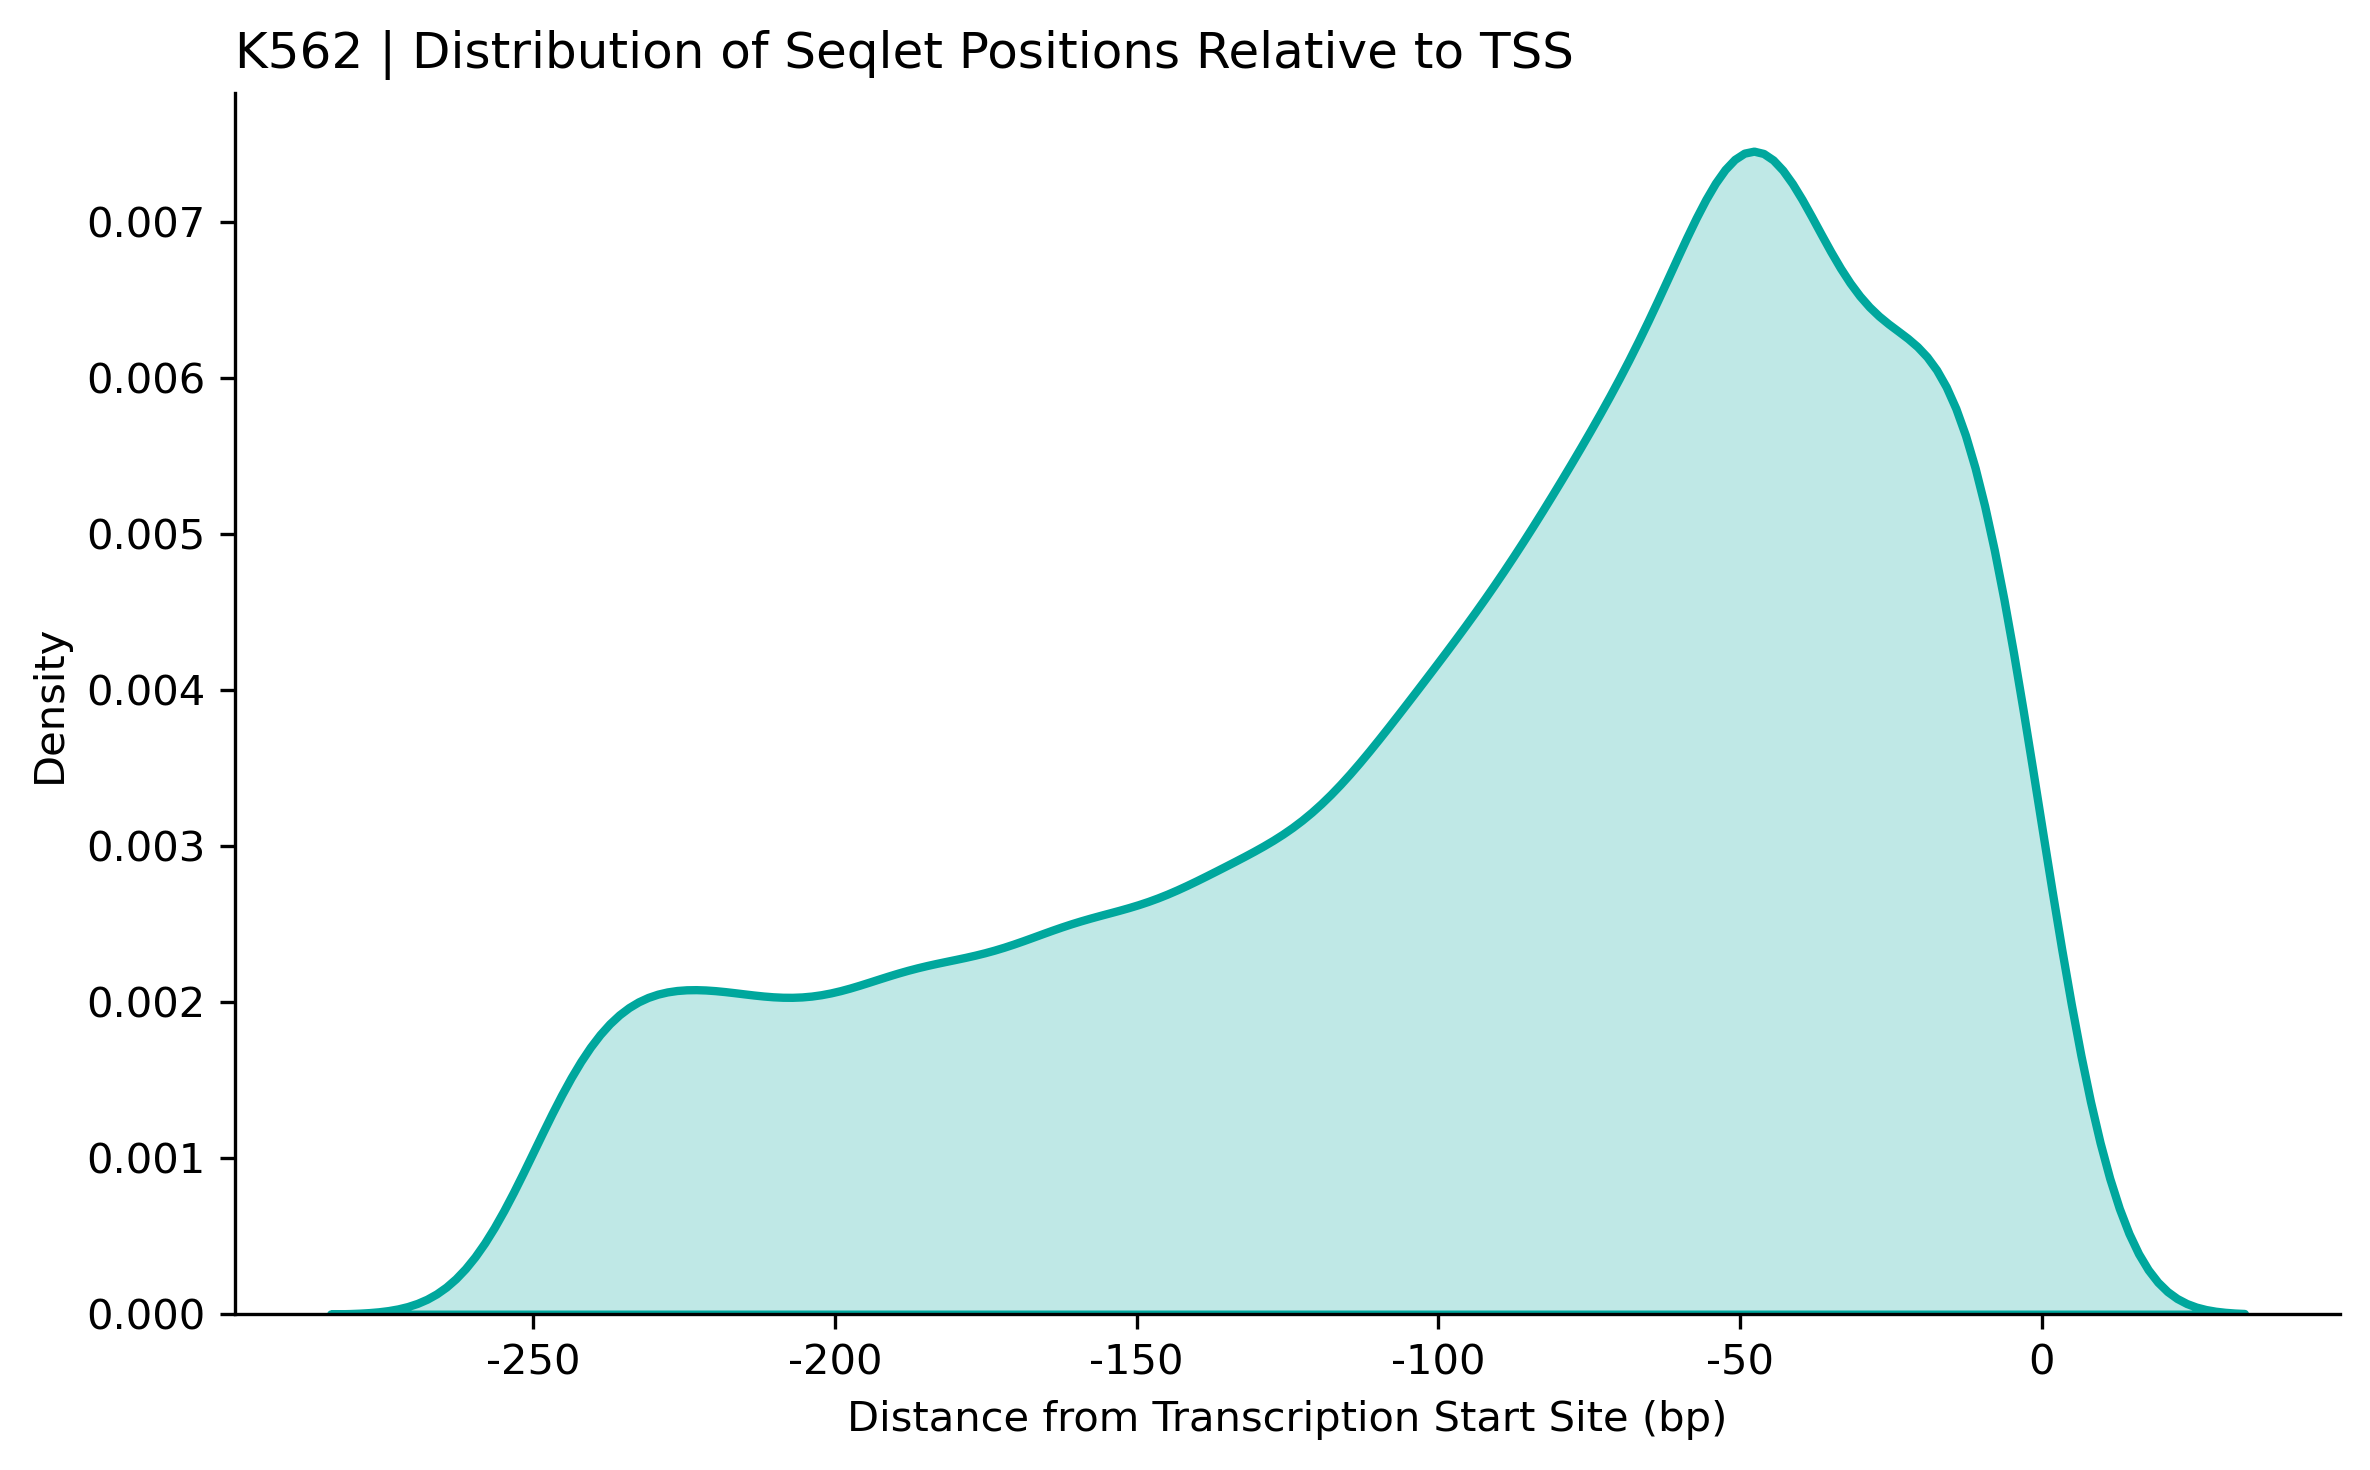

In [13]:
plot_tss_relative_seqlet_positions('../processed_data/bed_files/K562_bedOps_merged_noMin_seqlets_01_112225.bed',
                                   '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.exon.filtered.bed',
                                   'K562',
                                   '#00A79D',
                                   'x')

Loading and intersecting BED files...
Plotting distribution...


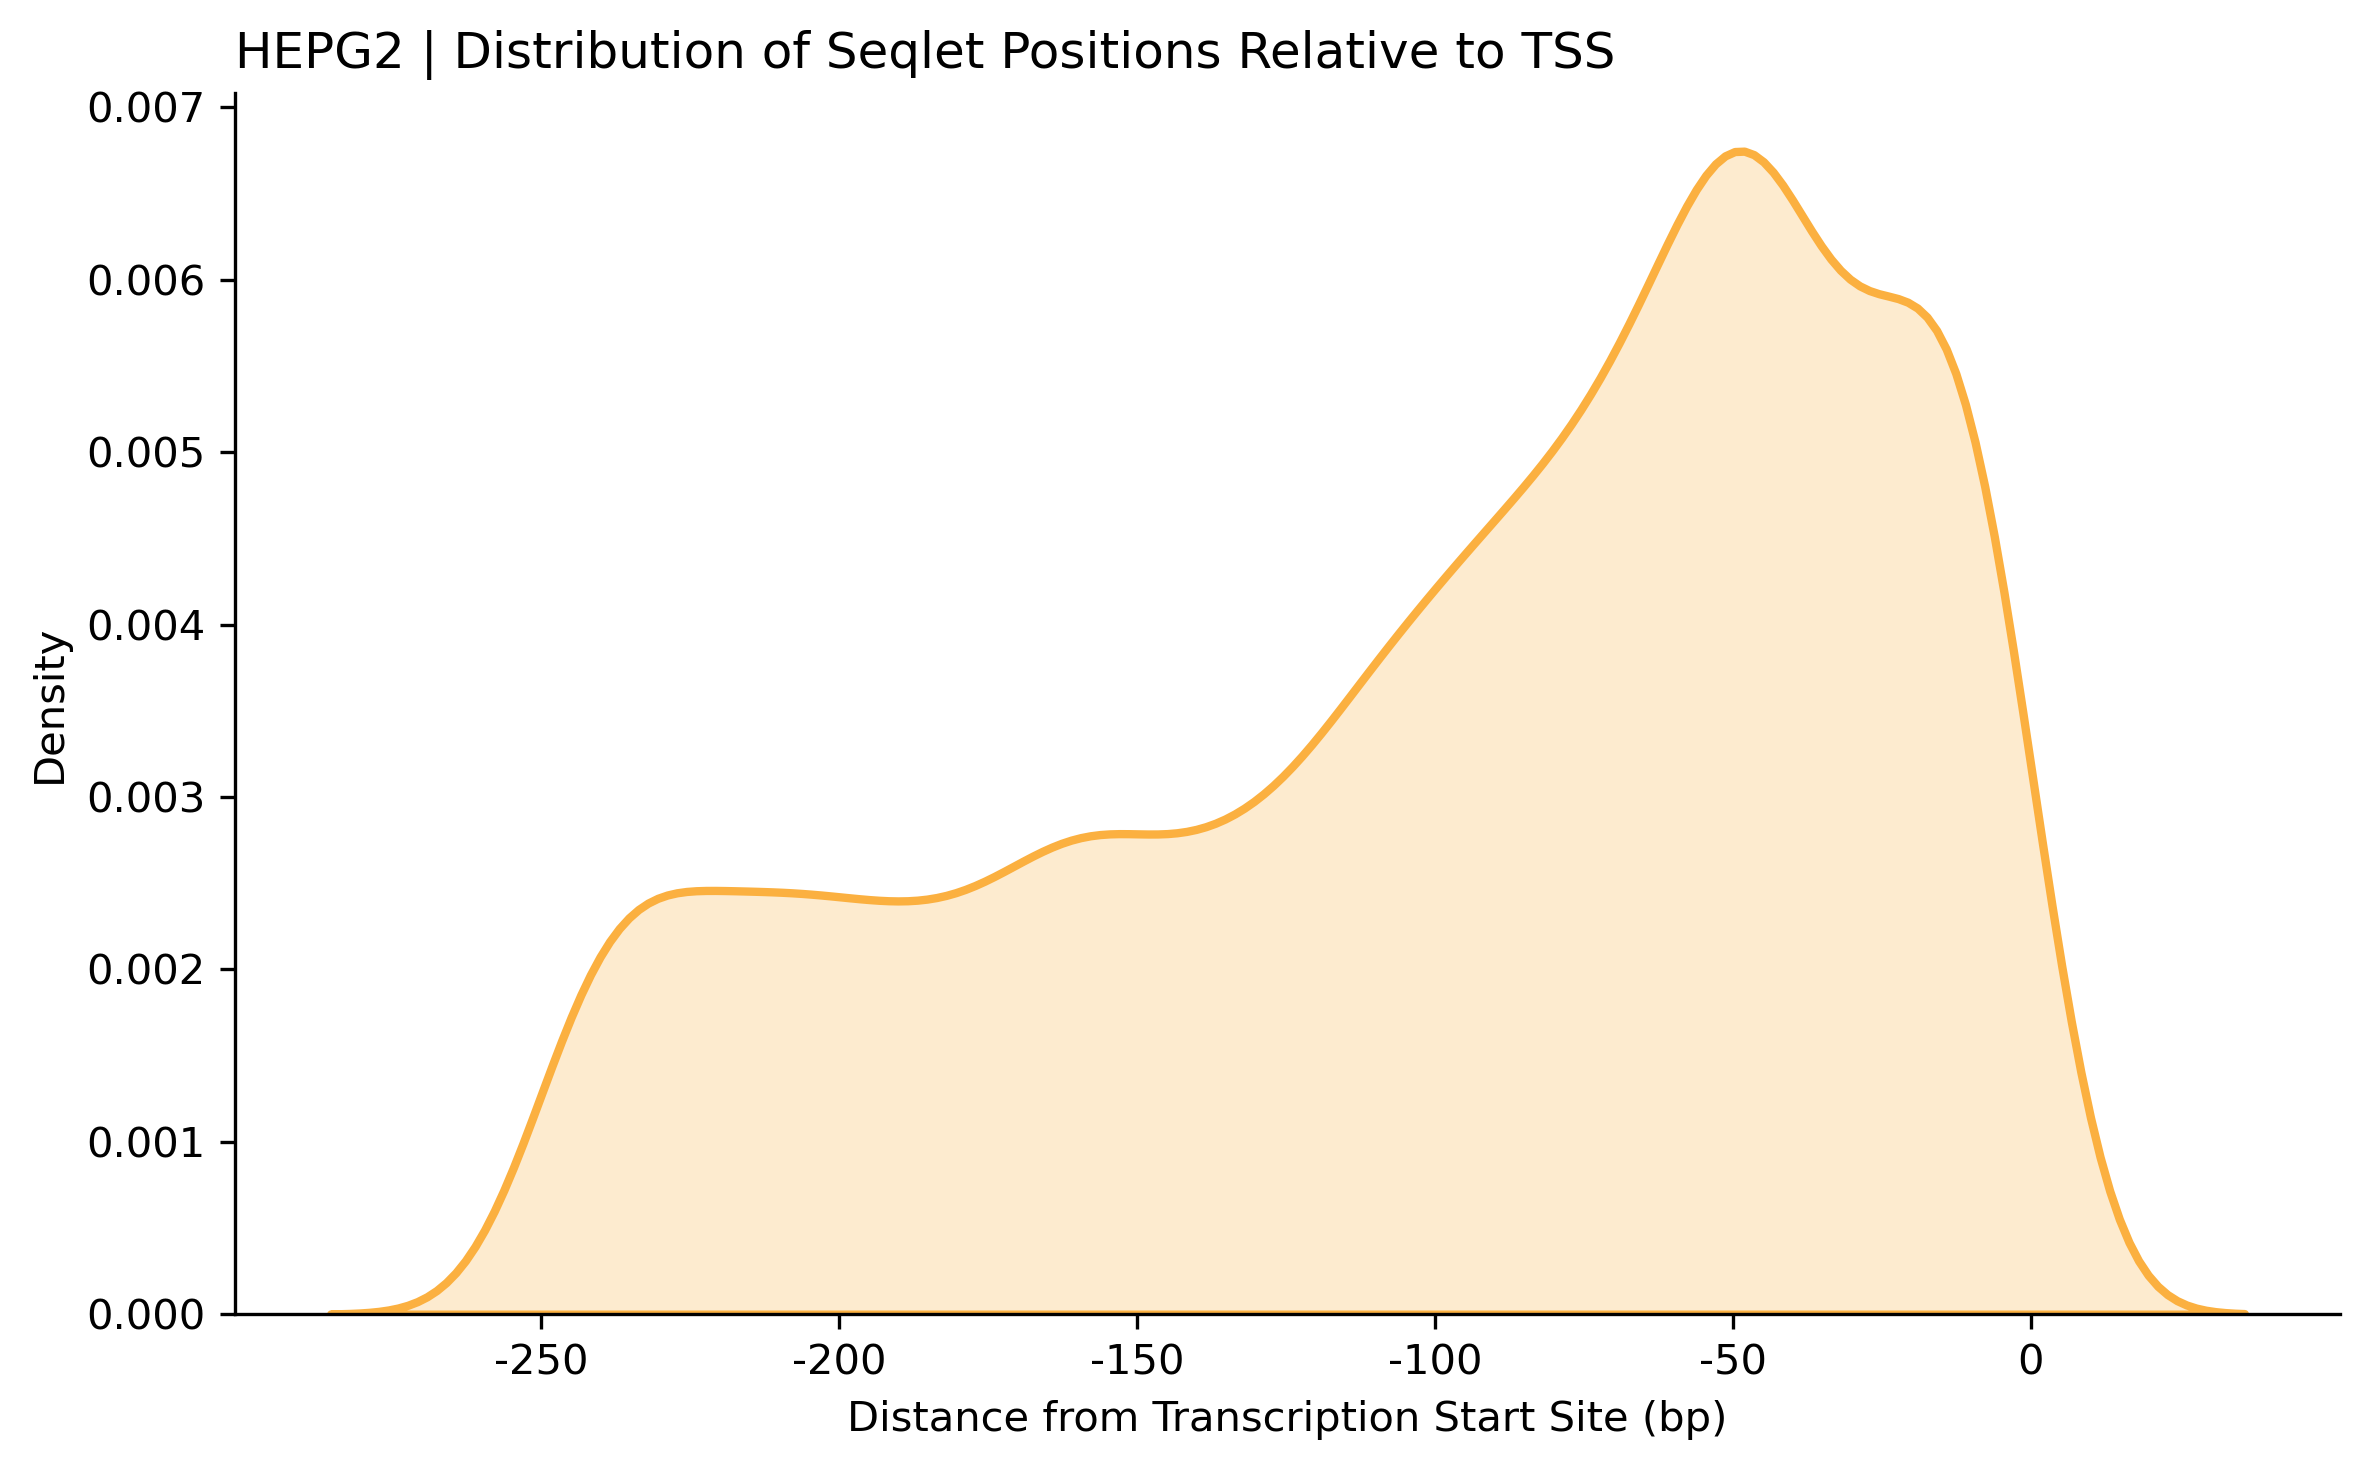

In [14]:
plot_tss_relative_seqlet_positions('../processed_data/bed_files/HepG2_bedOps_merged_noMin_seqlets_01_112225.bed',
                                   '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.exon.filtered.bed',
                                   'HepG2', 
                                   '#FBB040',
                                   'x')

Loading and intersecting BED files...
Plotting distribution...


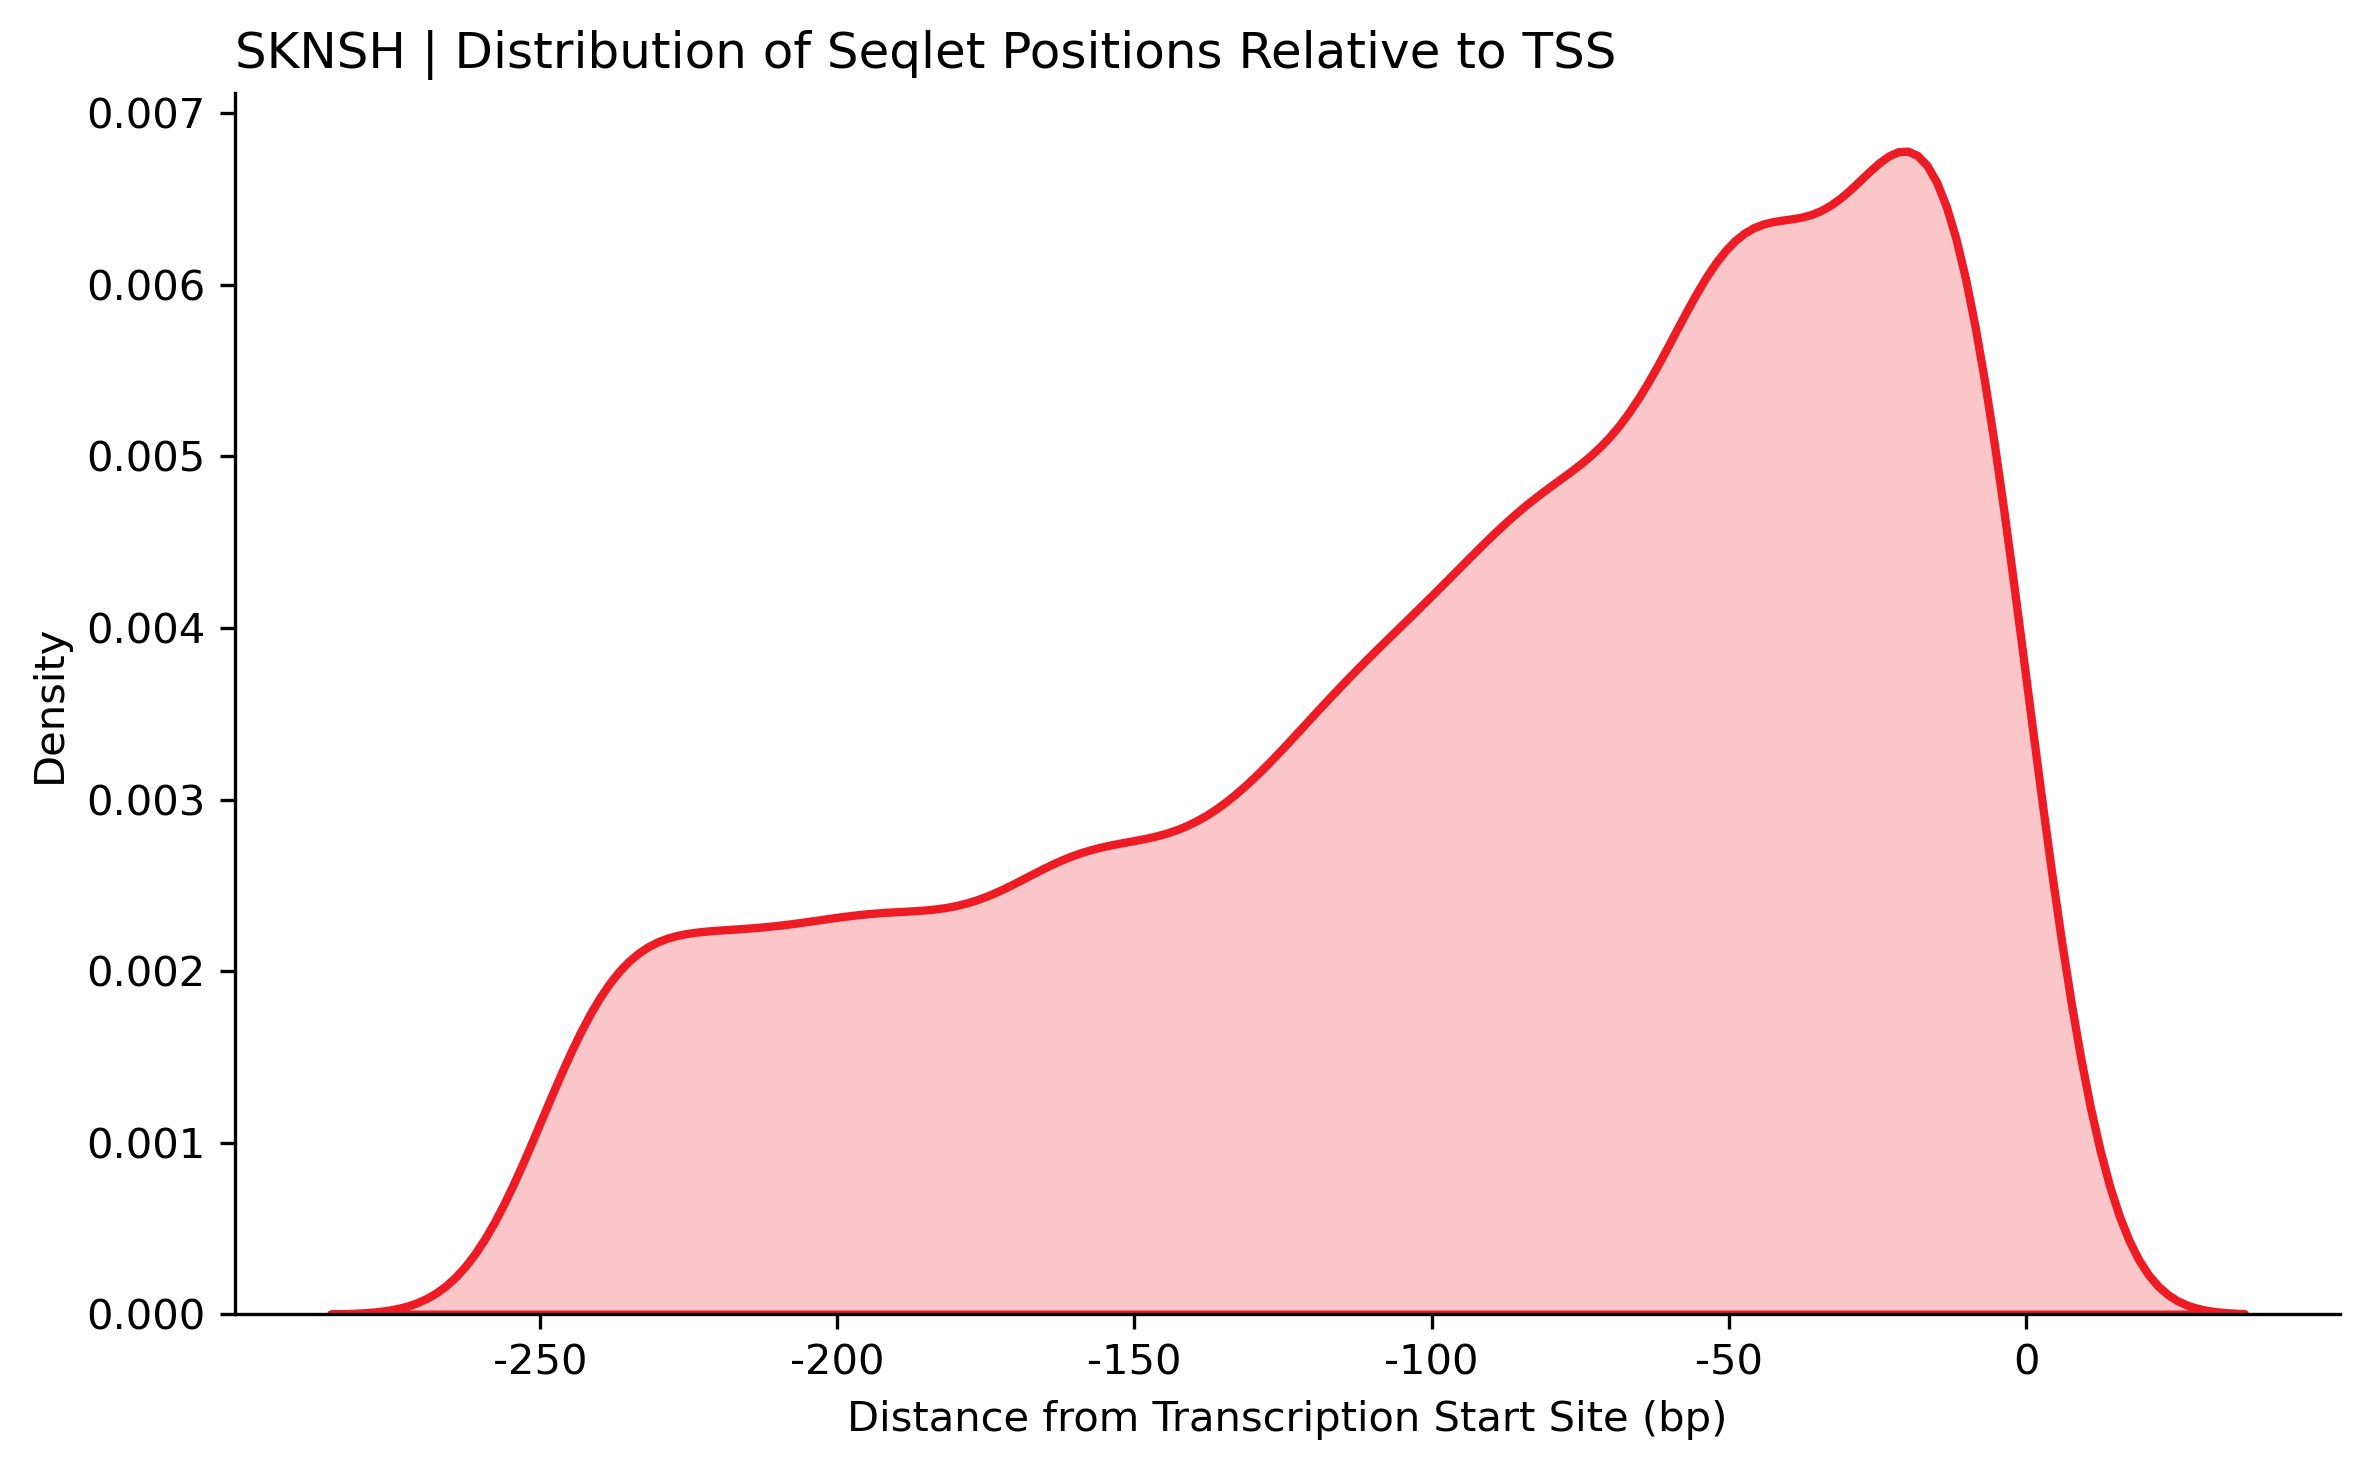

In [15]:
plot_tss_relative_seqlet_positions('../processed_data/bed_files/SKNSH_bedOps_merged_noMin_seqlets_01_112225.bed',
                                   '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.exon.filtered.bed',
                                   'SKNSH', 
                                   '#ED1C24',
                                   'x')

Loading and intersecting BED files...
Plotting distribution...


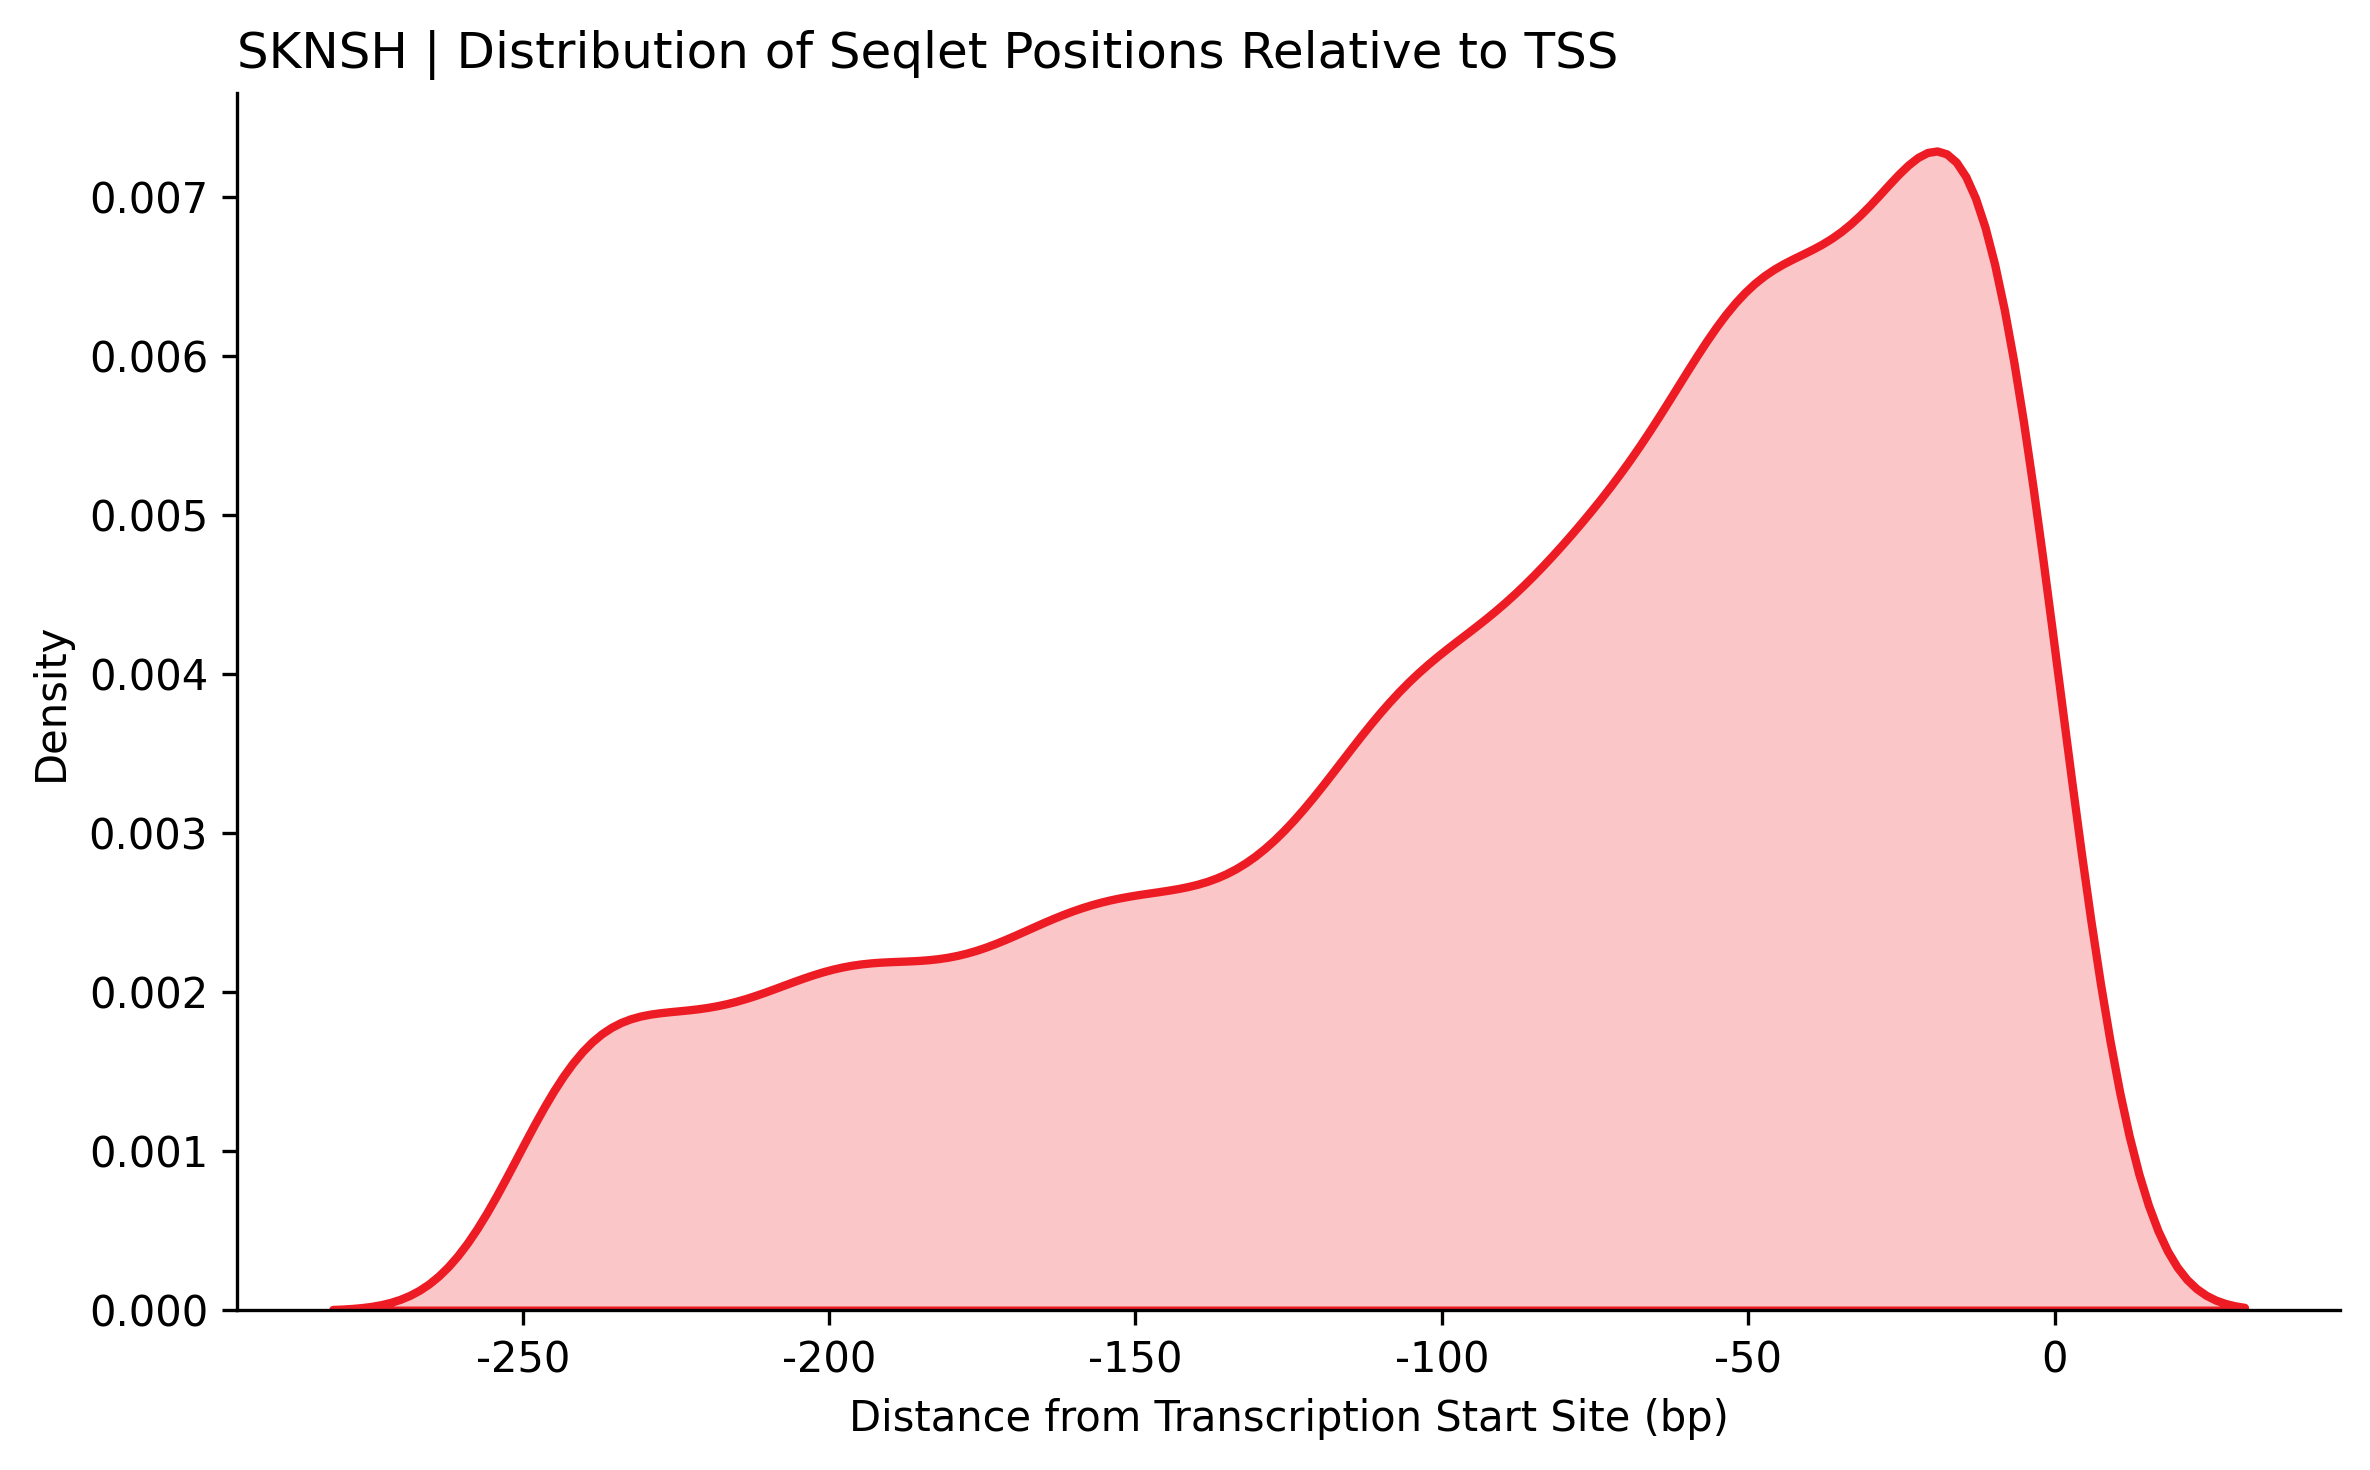

In [41]:
plot_tss_relative_seqlet_positions('../processed_data/bed_files/SKNSH_bedOps_merged_Min4ovr_seqlets_01.bed',
                                   '../raw_data/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.bed',
                                   'SKNSH', 
                                   '#ED1C24',
                                   'x')

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

def plot_tss_dist_from_collapsed(collapsed_df, promoters_bed_path, output_path, top_n=10):
    """
    Calculates and plots the TSS-relative positional distribution for the
    top N TFs using a pre-collapsed and classified DataFrame.

    Args:
        collapsed_df (pd.DataFrame): 
            DataFrame with merged intervals and columns 'representative_tf' 
            and 'activity_class'.
        promoters_bed_path (str): 
            Path to the promoter BED6 file (must include strand).
        output_path (str): 
            Path to save the output plot.
        top_n (int, optional): 
            The number of top TFs to plot for each class. Defaults to 10.
    """
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    # 1. Prepare DataFrames
    # Use pybedtools for the intersection
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Convert the collapsed df into a BedTool object in memory
    collapsed_bed = pybedtools.BedTool.from_dataframe(collapsed_df)
    
    # 2. Intersect collapsed intervals with promoters
    intersection = collapsed_bed.intersect(promoters, wa=True, wb=True)

    # The output will have 6 (collapsed) + 6 (promoter) = 12 columns
    df_intersect = intersection.to_dataframe(names=[
        'merged_chrom', 'merged_start', 'merged_end', 'merged_name', 
        'rep_tf', 'activity_class',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])
    
    # 3. Calculate position relative to TSS using the CENTER of the MERGED interval
    merged_center = (df_intersect['merged_start'] + df_intersect['merged_end']) / 2
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        merged_center - df_intersect['promo_start'],
        df_intersect['promo_end'] - merged_center
    )

    # 4. Identify top N TFs for each class from the collapsed data
    top_activators = df_intersect[df_intersect['activity_class'] == 'Activator']['rep_tf'].value_counts().head(top_n).index.tolist()
    top_repressors = df_intersect[df_intersect['activity_class'] == 'Repressor']['rep_tf'].value_counts().head(top_n).index.tolist()

    plot_df_activators = df_intersect[df_intersect['rep_tf'].isin(top_activators)]
    plot_df_repressors = df_intersect[df_intersect['rep_tf'].isin(top_repressors)]

    # 5. Create the two-panel plot
    print("Plotting distributions...")
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, dpi=300)
    
    # Plot Top Activators
    sns.kdeplot(data=plot_df_activators, x='tss_relative_pos', hue='rep_tf',
                palette='Greens_r', linewidth=2, ax=axes[0])
    axes[0].set_title(f'Top {top_n} Activator TFs', fontsize=14)
    axes[0].set_ylabel('Density')
    axes[0].legend(title='TF', bbox_to_anchor=(1.01, 1), loc='upper left')

    # Plot Top Repressors
    sns.kdeplot(data=plot_df_repressors, x='tss_relative_pos', hue='rep_tf',
                palette='Reds_r', linewidth=2, ax=axes[1])
    axes[1].set_title(f'Top {top_n} Repressor TFs', fontsize=14)
    axes[1].set_ylabel('Density')
    axes[1].set_xlabel('Distance from Transcription Start Site (bp)')
    axes[1].legend(title='TF', bbox_to_anchor=(1.01, 1), loc='upper left')

    sns.despine()
    fig.subplots_adjust(right=0.8)
    #plt.tight_layout()
    #plt.savefig(output_path, bbox_inches='tight')
    #plt.close()

    print(f"Final plot saved to: {output_path}")

In [18]:
plot_tss_dist_from_collapsed('../processed_data/bed_files/K562_bedOps_merged_noMin_seqlets_01_112225.bed',
                                   '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.exon.filtered.bed', 
                                    'x', 
                                    'K562',
                                    top_n=10)

TypeError: plot_tss_dist_from_collapsed() got multiple values for argument 'top_n'

Finding and processing seqlet positions within promoters...
Plotting distributions...


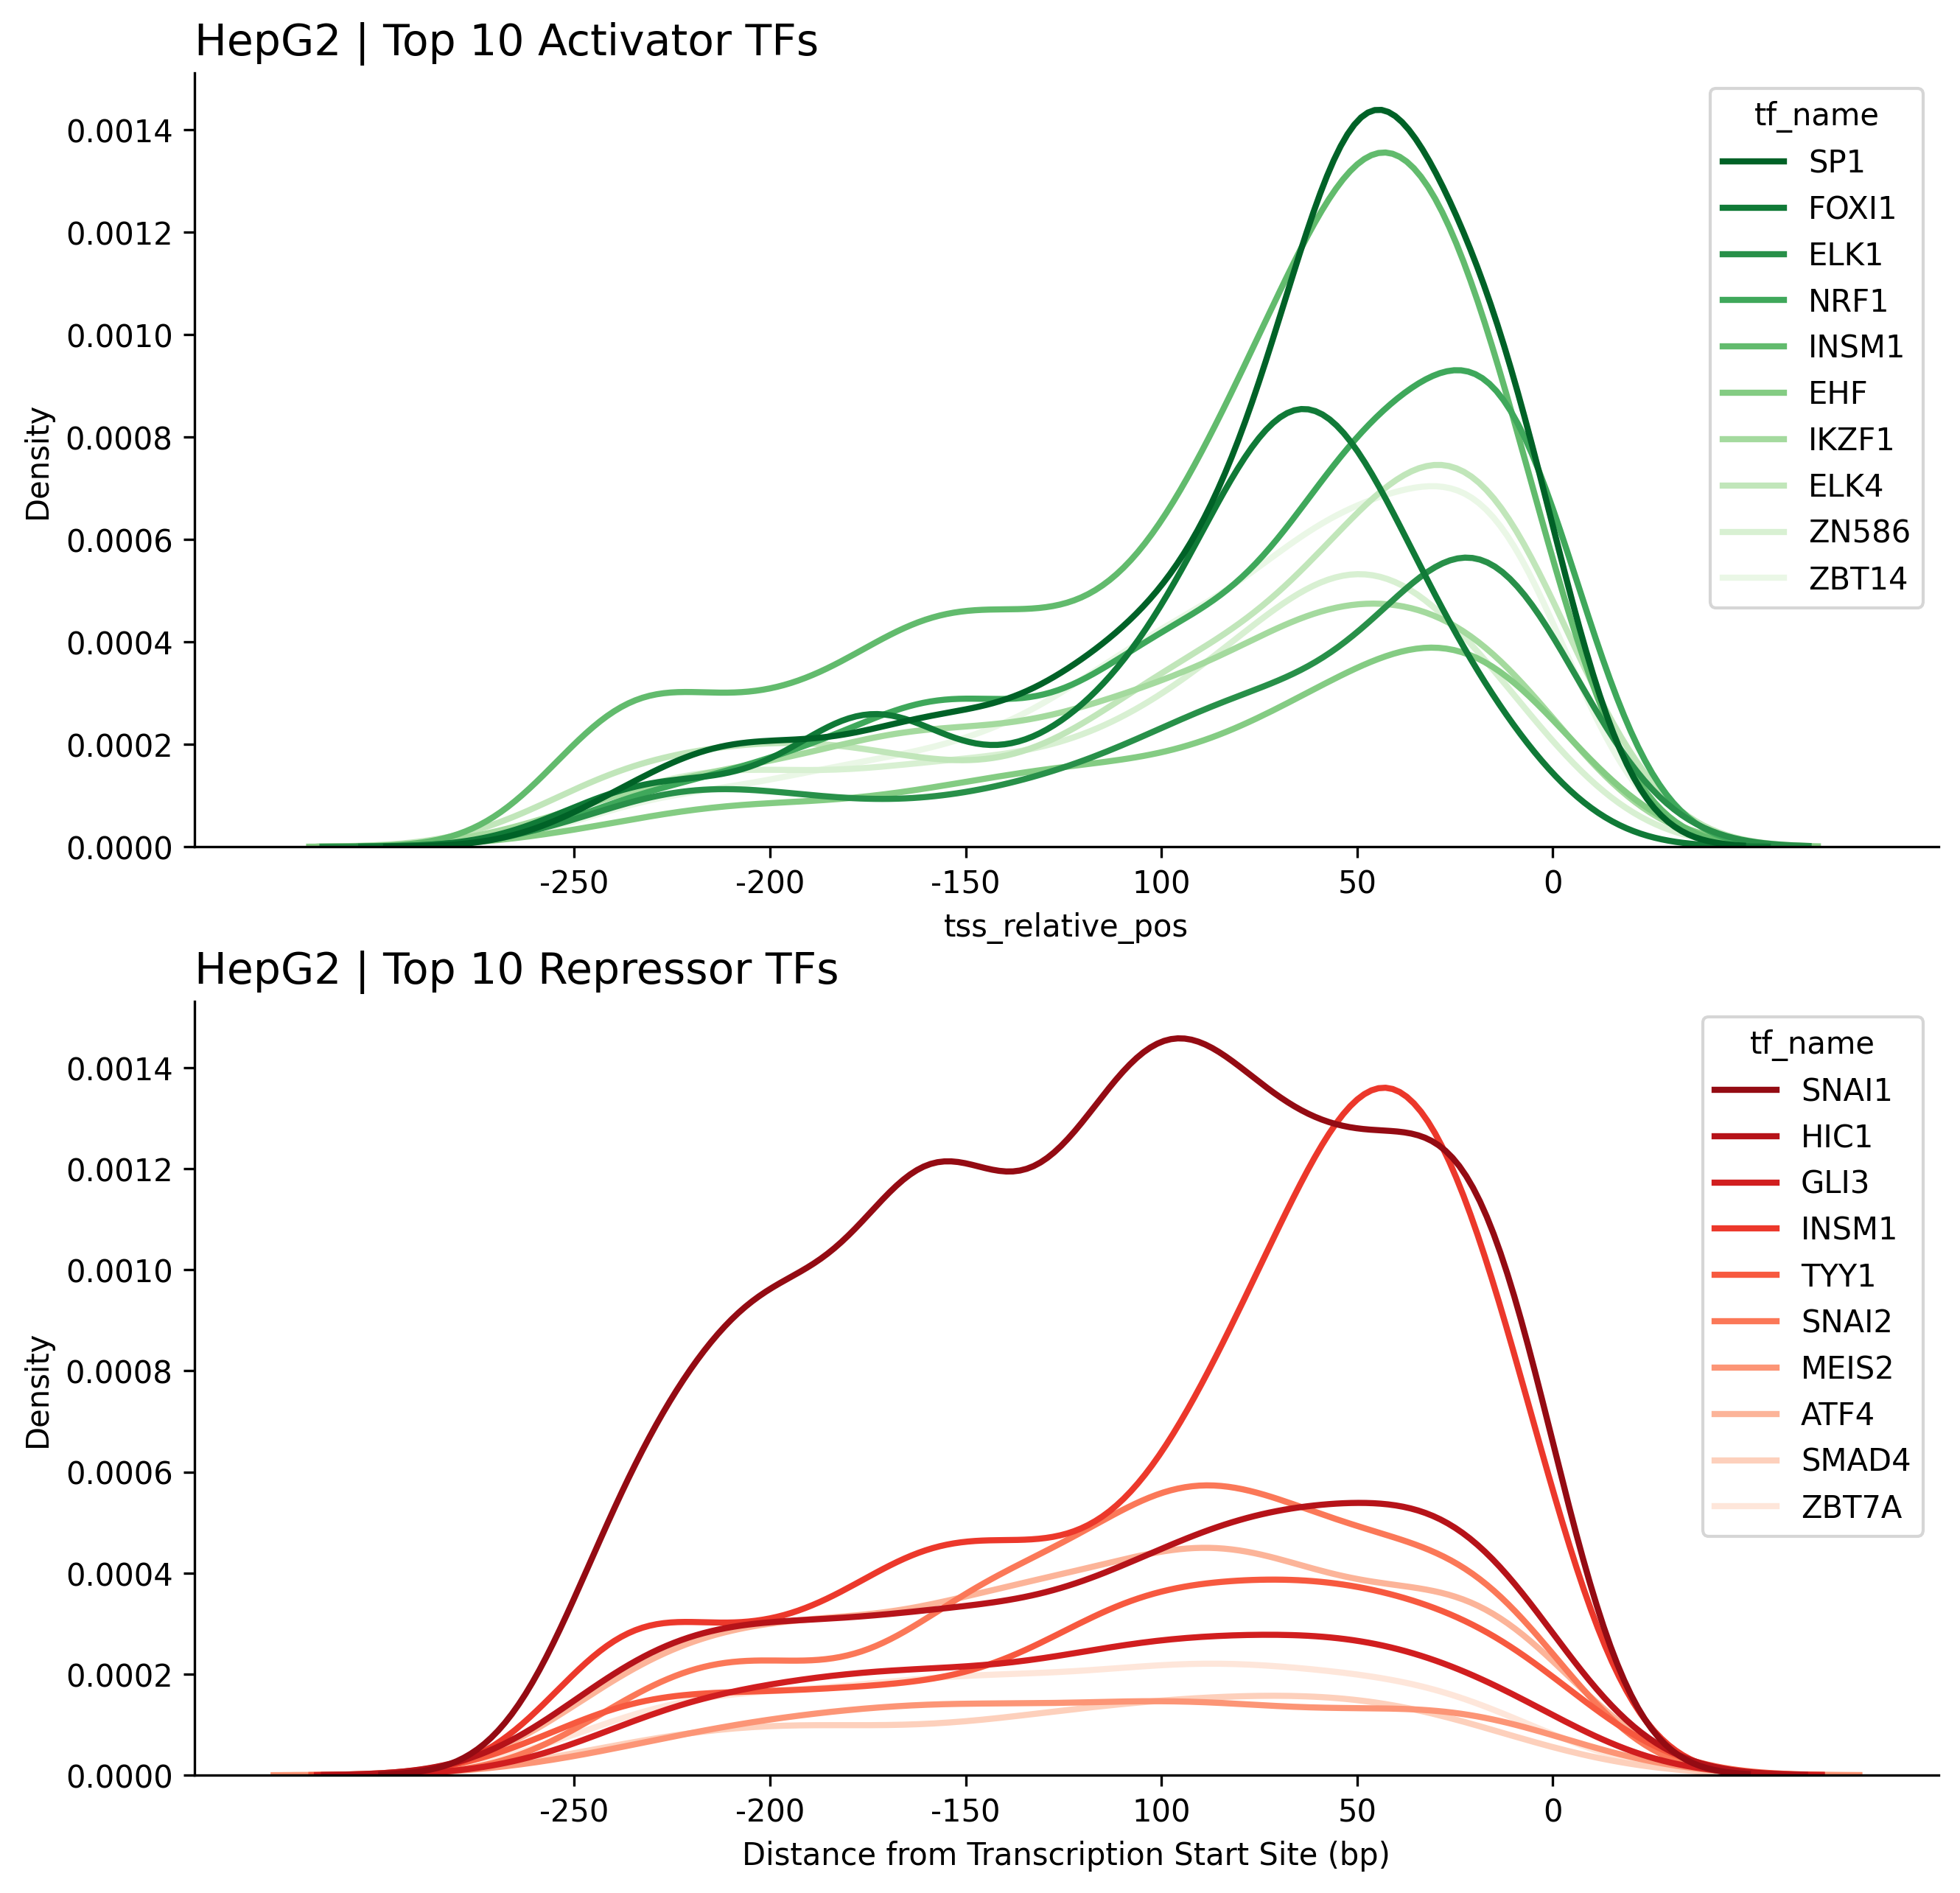

In [81]:
plot_top_activity_tss_distributions('../processed_data/bed_files/HepG2_bedOps_merged_noMin_seqlets_01.bed',
                                   '../raw_data/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.bed', 
                                    'x', 
                                    'HepG2',
                                    top_n=10)

Finding and processing seqlet positions within promoters...
Plotting distributions...


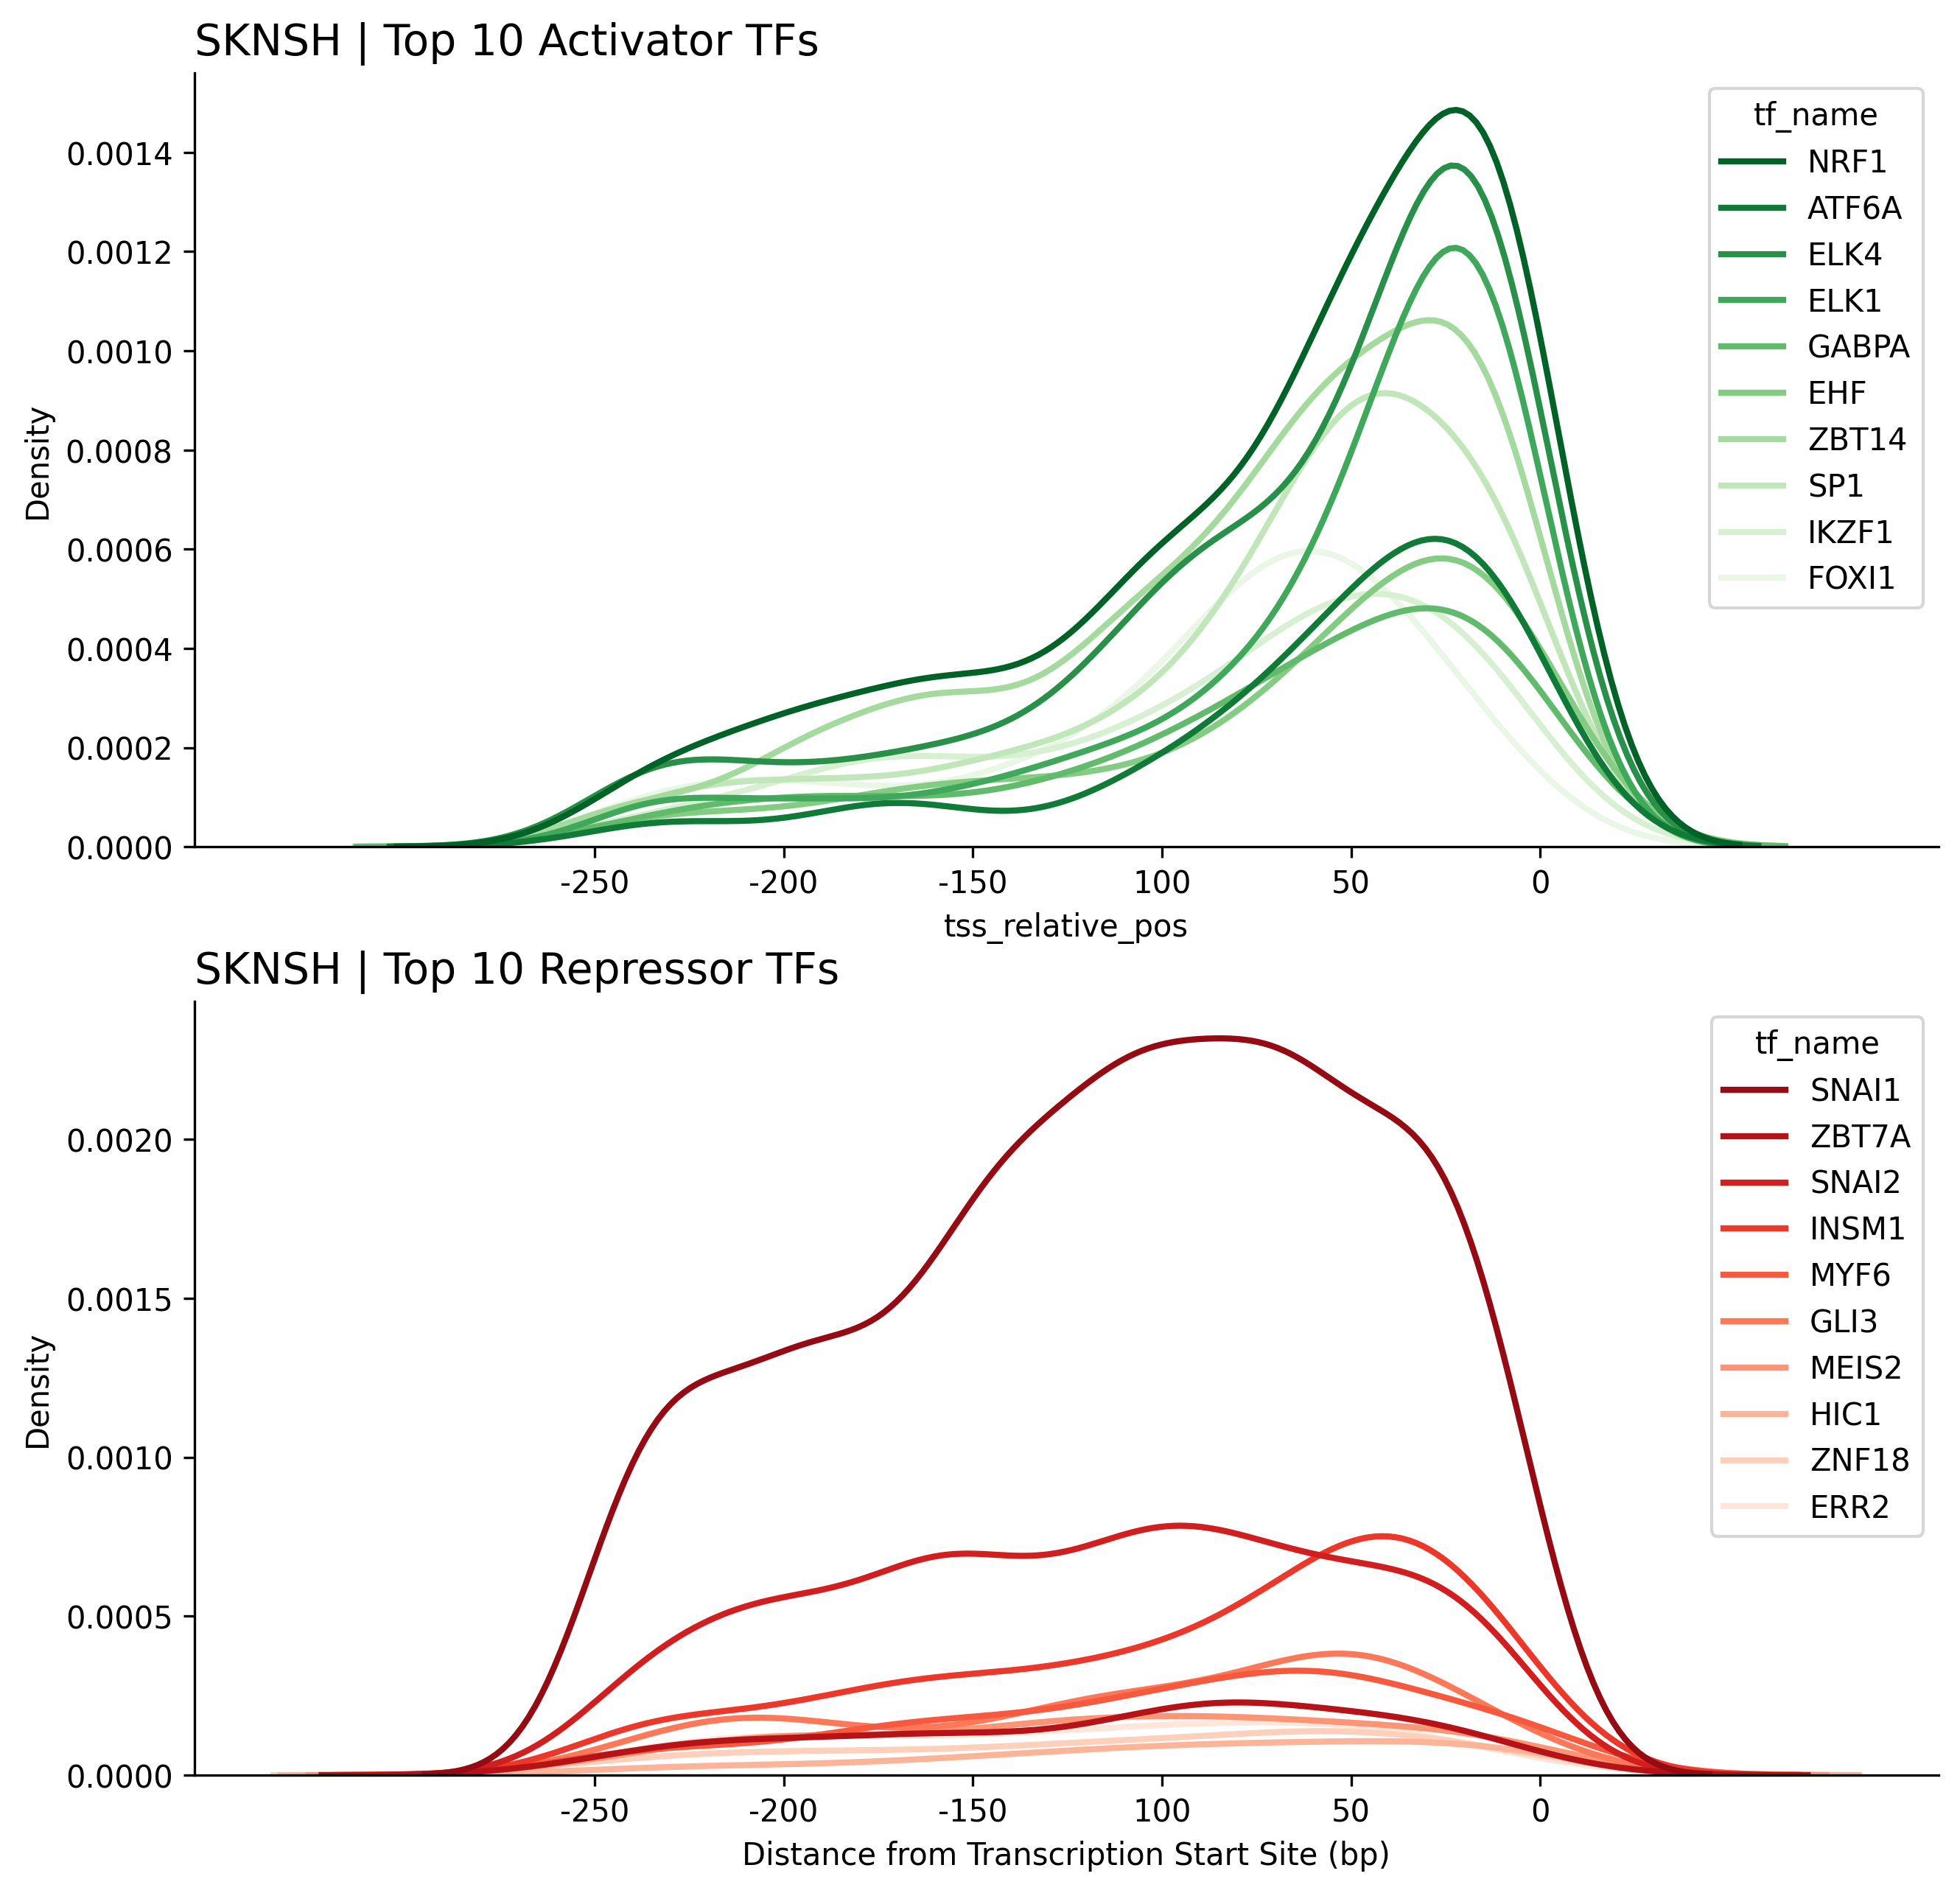

In [82]:
plot_top_activity_tss_distributions('../processed_data/bed_files/SKNSH_bedOps_merged_noMin_seqlets_01.bed',
                                   '../raw_data/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.bed', 
                                    'x', 
                                    'SKNSH',
                                    top_n=10)

In [84]:
# define function to convert predictions to final df
def vcf2df (pred_df):
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    gene_name = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df[7]):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
        # add annotated gene name
        gene_name.append(all_preds[-1].split('=')[-1])
    
    df = pd.DataFrame({'chrom' : pred_df[0],
                       'pos' : pred_df[1],
                       'id' : pred_df[2],
                       'ref' : pred_df[3],
                       'alt' : pred_df[4],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew,
                       'gene_name' : gene_name})
    return df

In [85]:
# open tabix filtered (tabix_filter_mpac_preds.sh) predictions and reformat for downstream analyses
all_tabix_mpac_preds = vcf2df(pd.read_csv('../mpac/processed_data/all.mpac.preds.tabix.filtered.gencode.250bp.vcf', sep = '\t', header = None))

100%|██████████| 12379545/12379545 [00:56<00:00, 220823.03it/s]


In [86]:
all_tabix_mpac_preds

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,gene_name
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,-0.022653,0.558187,0.530182,-0.028004,OR4F5
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,-0.005339,0.558187,0.547707,-0.010479,OR4F5
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,-0.004132,0.558187,0.539187,-0.019000,OR4F5
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,0.059047,0.538484,0.640290,0.101806,OR4F5
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,T,0.287499,0.278900,-0.008599,0.352586,0.349975,-0.002611,0.538484,0.525039,-0.013445,OR4F5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12379540,chr22,50783916,ENSG00000079974.19_ENST00000691320.1_RABL2B..c...,T,C,1.227027,1.288358,0.061331,0.890974,0.937690,0.046716,0.756404,0.761580,0.005176,RABL2B
12379541,chr22,50783916,ENSG00000079974.19_ENST00000691320.1_RABL2B..c...,T,G,1.227027,1.273099,0.046072,0.890974,0.908481,0.017507,0.756404,0.759925,0.003521,RABL2B
12379542,chr22,50783917,ENSG00000079974.19_ENST00000691320.1_RABL2B..c...,T,A,1.262193,1.260112,-0.002082,0.904990,0.901146,-0.003845,0.758988,0.739328,-0.019661,RABL2B
12379543,chr22,50783917,ENSG00000079974.19_ENST00000691320.1_RABL2B..c...,T,C,1.262193,1.291161,0.028968,0.904990,0.940778,0.035788,0.758988,0.786619,0.027630,RABL2B


In [97]:
all_tabix_mpac_mean = all_tabix_mpac_preds.groupby('gene_name')[['k562_ref_pred', 'hepg2_ref_pred', 'sknsh_ref_pred']].mean().reset_index()

In [98]:
all_tabix_mpac_mean

,gene_name,k562_ref_pred,hepg2_ref_pred,sknsh_ref_pred
0,A1BG,1.097115,1.449478,0.705833
1,A1CF,0.467031,1.864138,0.295851
2,A2M,0.383165,0.419348,0.663724
3,A2ML1,0.044518,0.040276,0.030979
4,A3GALT2,1.509699,1.310147,1.096112
...,...,...,...,...
16280,ZYG11A,0.304736,0.275921,0.236925
16281,ZYG11B,3.004617,2.288211,2.507357
16282,ZYX,5.053576,4.245267,4.622927
16283,ZZEF1,3.546370,2.952198,3.725481


In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

def seqlet_summary_single_group(path2bedtools_coverage,
                                 cell_type,
                                 mean_preds,
                                 min_overlap):
    """
    Generates a 5-panel summary plot for a single group of enhancers.
    """
    # --- Data Loading and Preparation ---
    coverage_cols = [
        'cre_chrom', 'cre_start', 'cre_end', 'promoter', 'cre_id', 'cre_strand',
        'n_seqlets', 'n_bases_covered', 'cre_length', 'fraction_covered'
    ]
    bed_covers = pd.read_csv(path2bedtools_coverage, sep='\t', header=None, names=coverage_cols)
    bed_covers = bed_covers[bed_covers['cre_chrom'] != 'chrX']
    
    bed_covers['seqlet_density'] = (bed_covers['n_seqlets'] / (bed_covers['cre_length'] + 1e-9)) * 50
    
    ref_pred_dict = dict(zip(mean_preds['gene_name'], mean_preds[f'{cell_type.lower()}_ref_pred']))
    bed_covers[f'{cell_type}_ref_pred'] = bed_covers['promoter'].map(ref_pred_dict)
    bed_covers.dropna(subset=[f'{cell_type}_ref_pred'], inplace=True)
    
    if bed_covers.empty:
        print(f"Warning: No data remains for {cell_type} after processing. Skipping plot.")
        return

    # --- FIX: Replaced dynamic binning with a robust, fixed method ---
    # Define robust bins that go to infinity and their corresponding labels
    bins = [0, 1, 2, 5, 10, np.inf]
    bin_labels = ['0', '1', '2-4', '5-9', '10+']

    # Create the 'seqlet_bin' column using these fixed bins
    bed_covers['seqlet_bin'] = pd.cut(
        bed_covers['n_seqlets'],
        bins=bins,
        labels=bin_labels,
        right=False  # Intervals are [start, end), so bin [0,1) is 0.
    )
    # --- Plotting Setup ---
    # Define a single color for the cell type
    if cell_type.lower() == 'k562':
        plot_color = '#00A79D'
    elif cell_type.lower() == 'hepg2':
        plot_color = '#FBB040'
    else: # sknsh
        plot_color = '#ED1C24'
    
    # Use a 2x3 grid and hide the last panel
    f, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)
    axes = axes.flatten()
    
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    # --- Create All Plots for the Single Group ---
    # Panel 1: n_seqlets (ECDF)
    sns.ecdfplot(data=bed_covers, x='n_seqlets', color=plot_color, ax=axes[0])
    axes[0].set_title(f'{cell_type.upper()} | merge min overlap: {min_overlap} | n dELS: {len(bed_covers)}', loc='left')
    axes[0].set_xlabel("n_seqlets")

    # Panel 2: fraction_covered (ECDF)
    sns.ecdfplot(data=bed_covers, x='fraction_covered', color=plot_color, ax=axes[1])
    axes[1].set_ylabel("")

    # Panel 3: seqlet_density (ECDF)
    sns.ecdfplot(data=bed_covers, x='seqlet_density', color=plot_color, ax=axes[2])
    axes[2].set_xlabel('Seqlets per 50bp')
    axes[2].set_ylabel("")

    # Panel 4: Violin plot for ref_pred
    sns.violinplot(data=bed_covers, x='seqlet_bin', y=f'{cell_type}_ref_pred', color=plot_color, ax=axes[3], inner='quartile', linewidth=0.8)
    axes[3].tick_params(axis='x', rotation=45)
    axes[3].set_ylabel(f'{cell_type.upper()} ref_pred')
    # Hide the unused 5th panel
    axes[4].set_visible(False)

    # Hide the unused 6th panel
    axes[5].set_visible(False)

    sns.despine()
    plt.tight_layout()

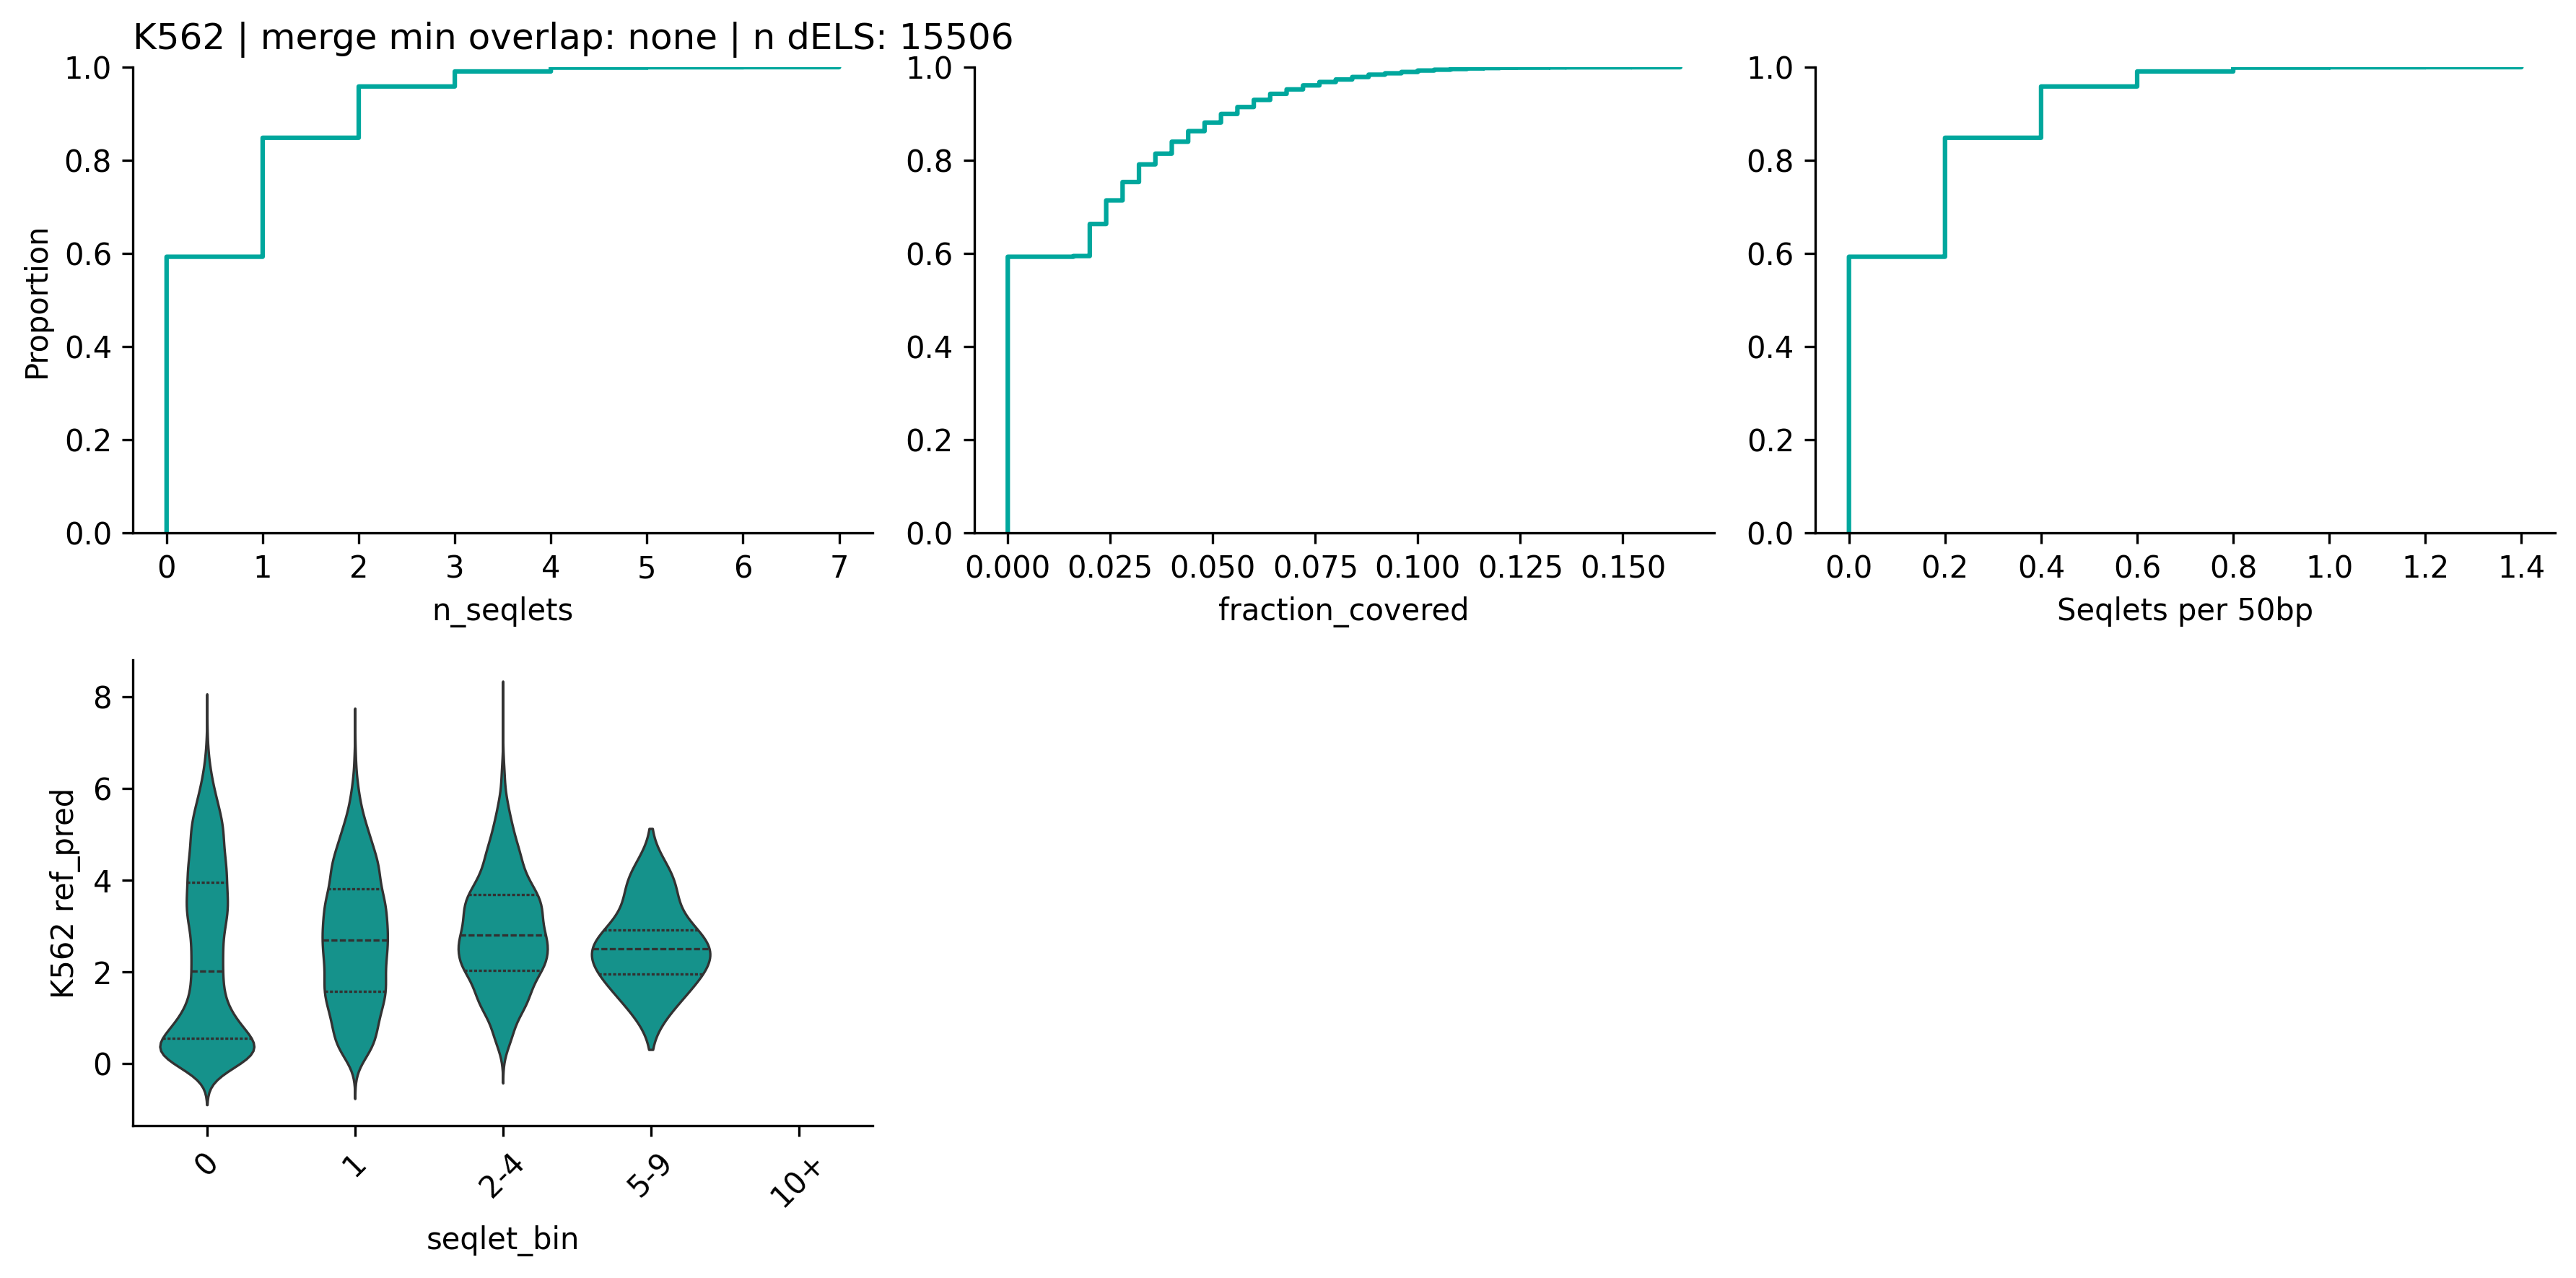

In [105]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/K562_01_noMin_250bp_pro_cover.bed',
                            'k562',
                            all_tabix_mpac_mean,
                            'none')

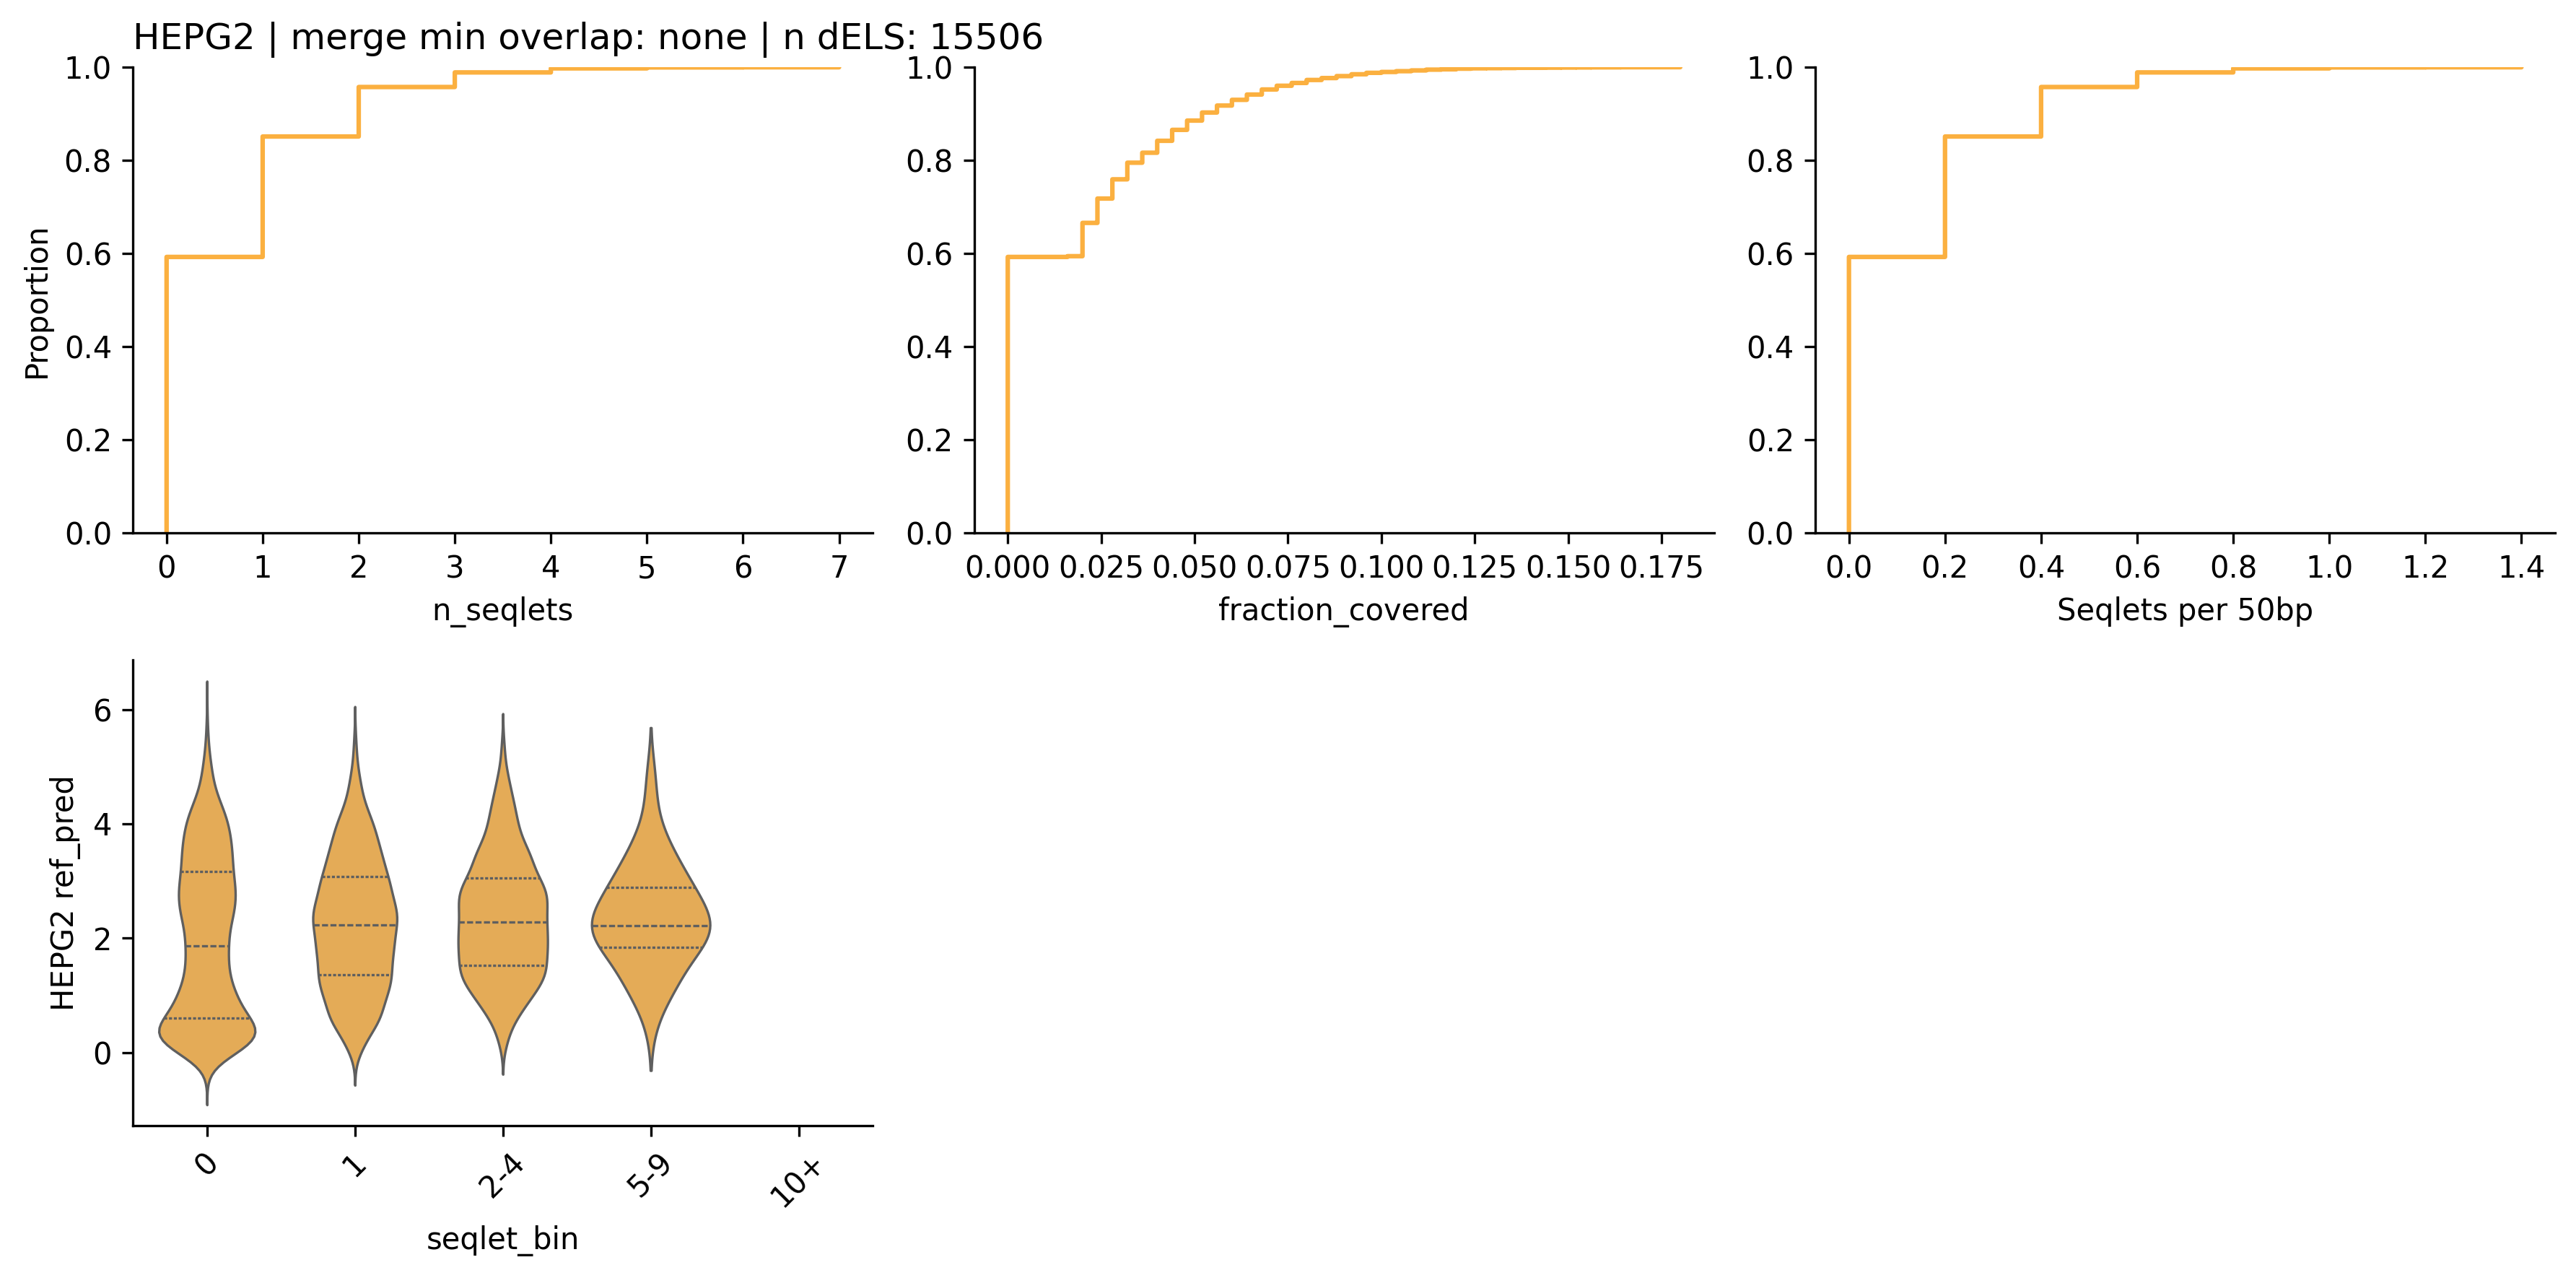

In [106]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/HepG2_01_noMin_250bp_pro_cover.bed',
                            'hepg2',
                            all_tabix_mpac_mean,
                            'none')

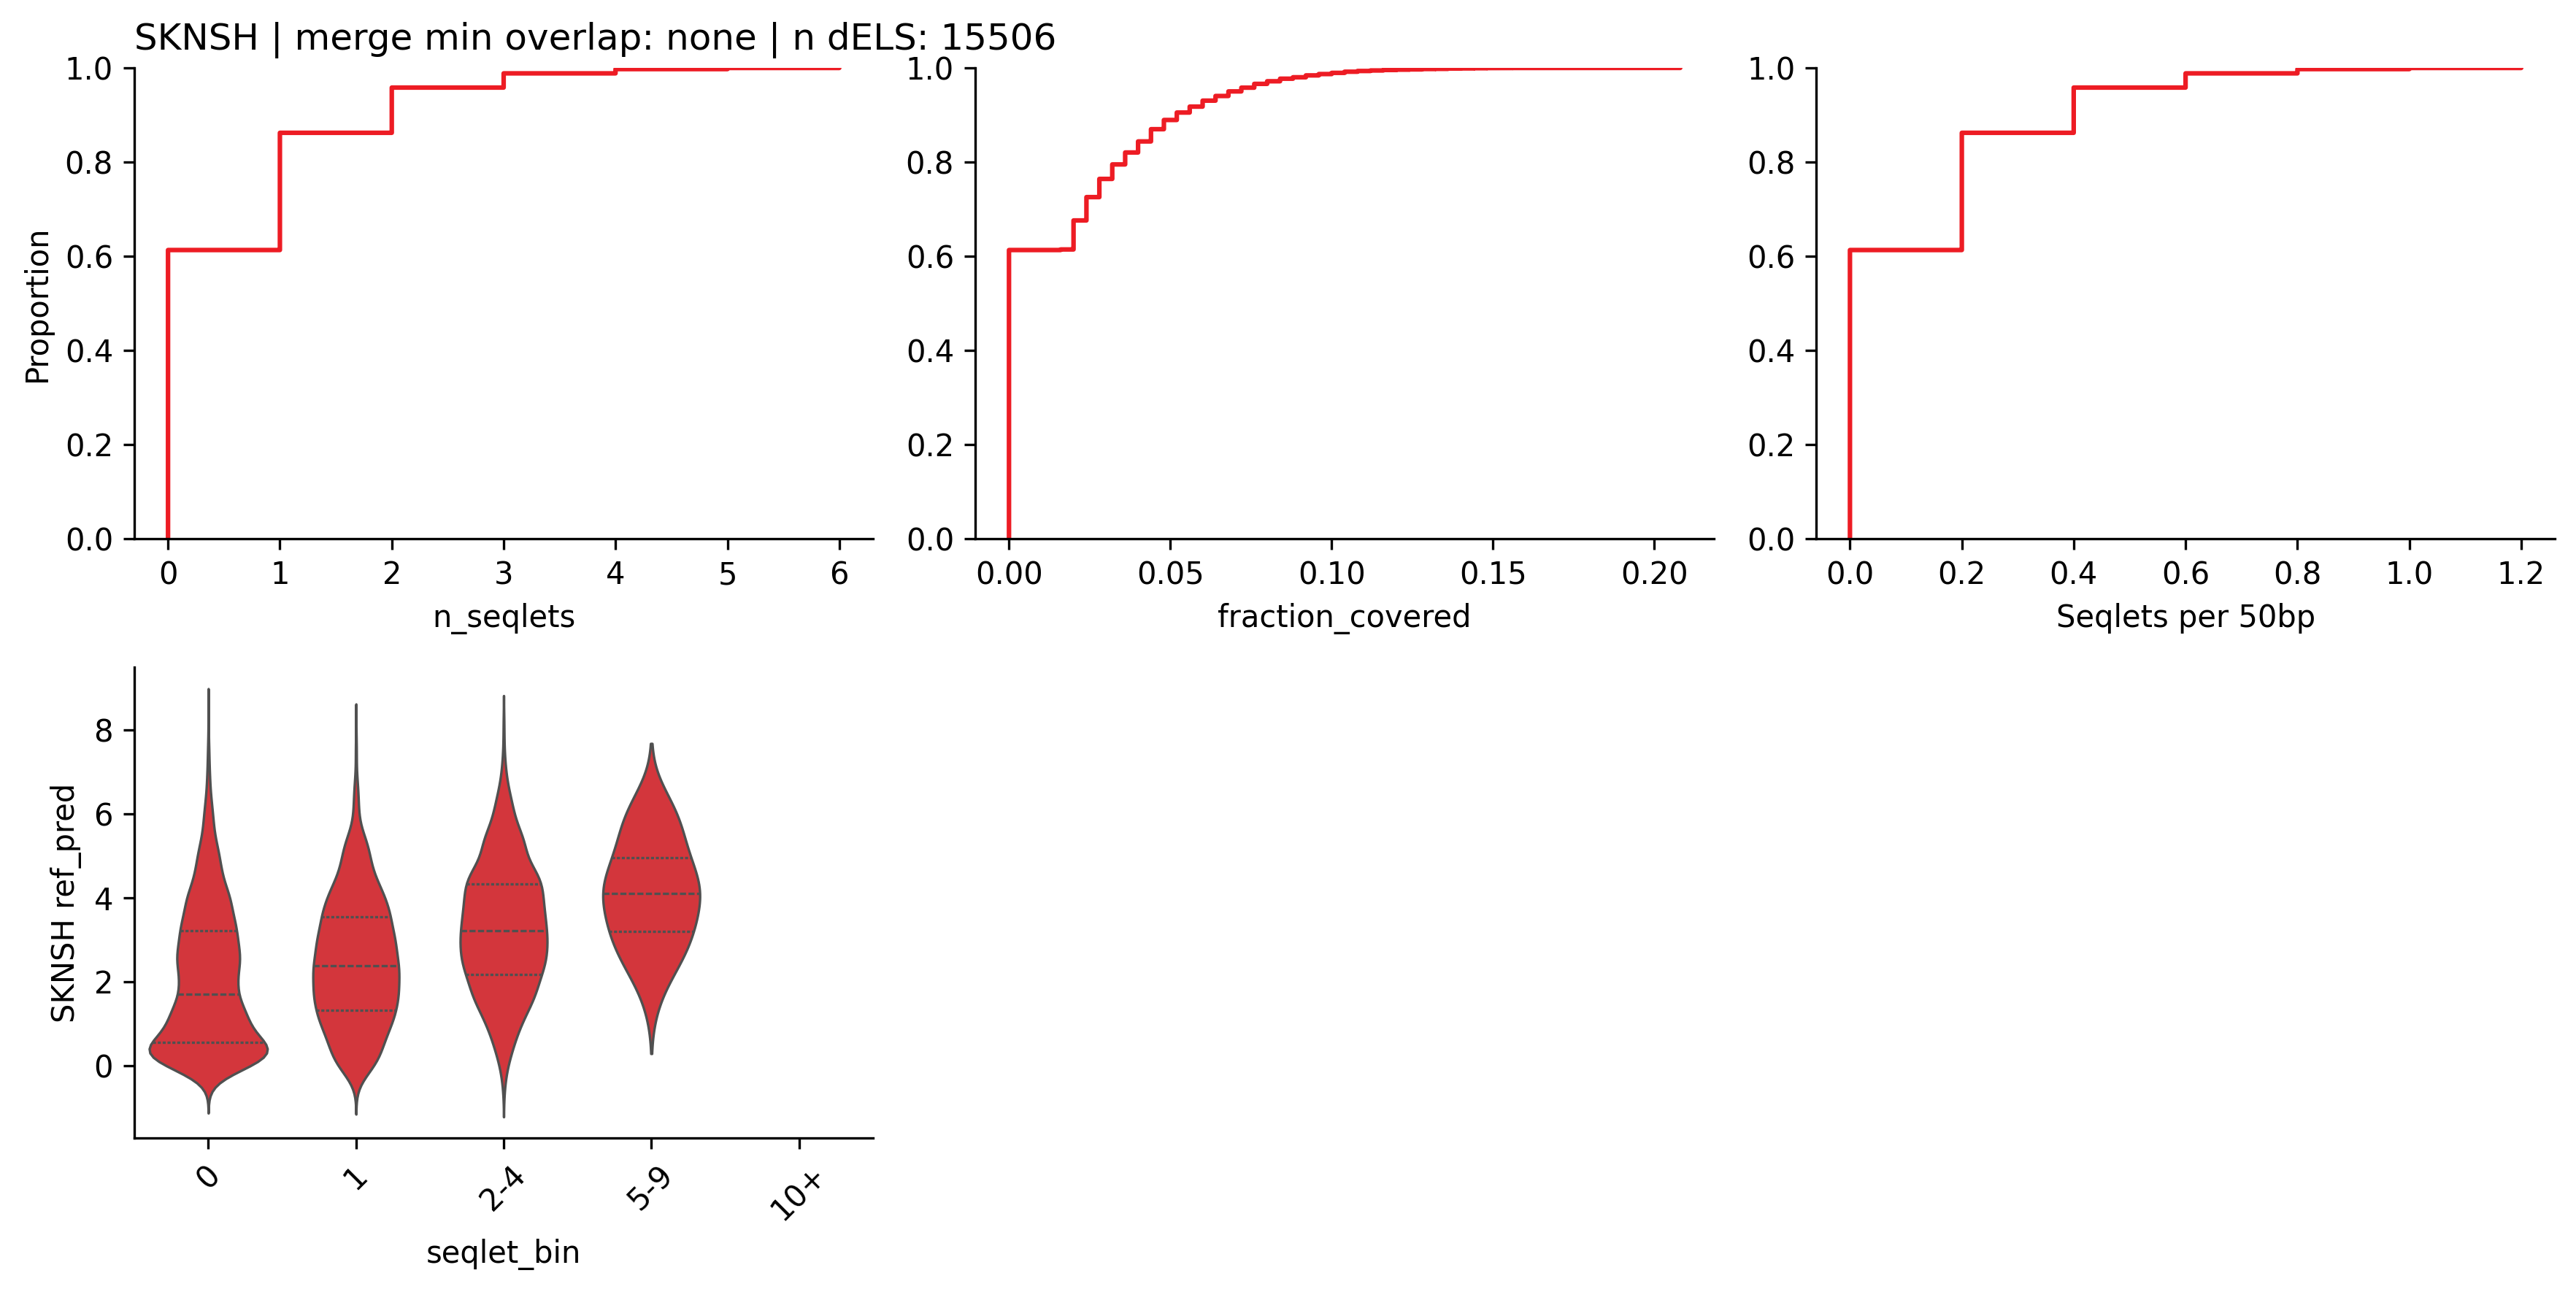

In [107]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/SKNSH_01_noMin_250bp_pro_cover.bed',
                            'sknsh',
                            all_tabix_mpac_mean,
                            'none')

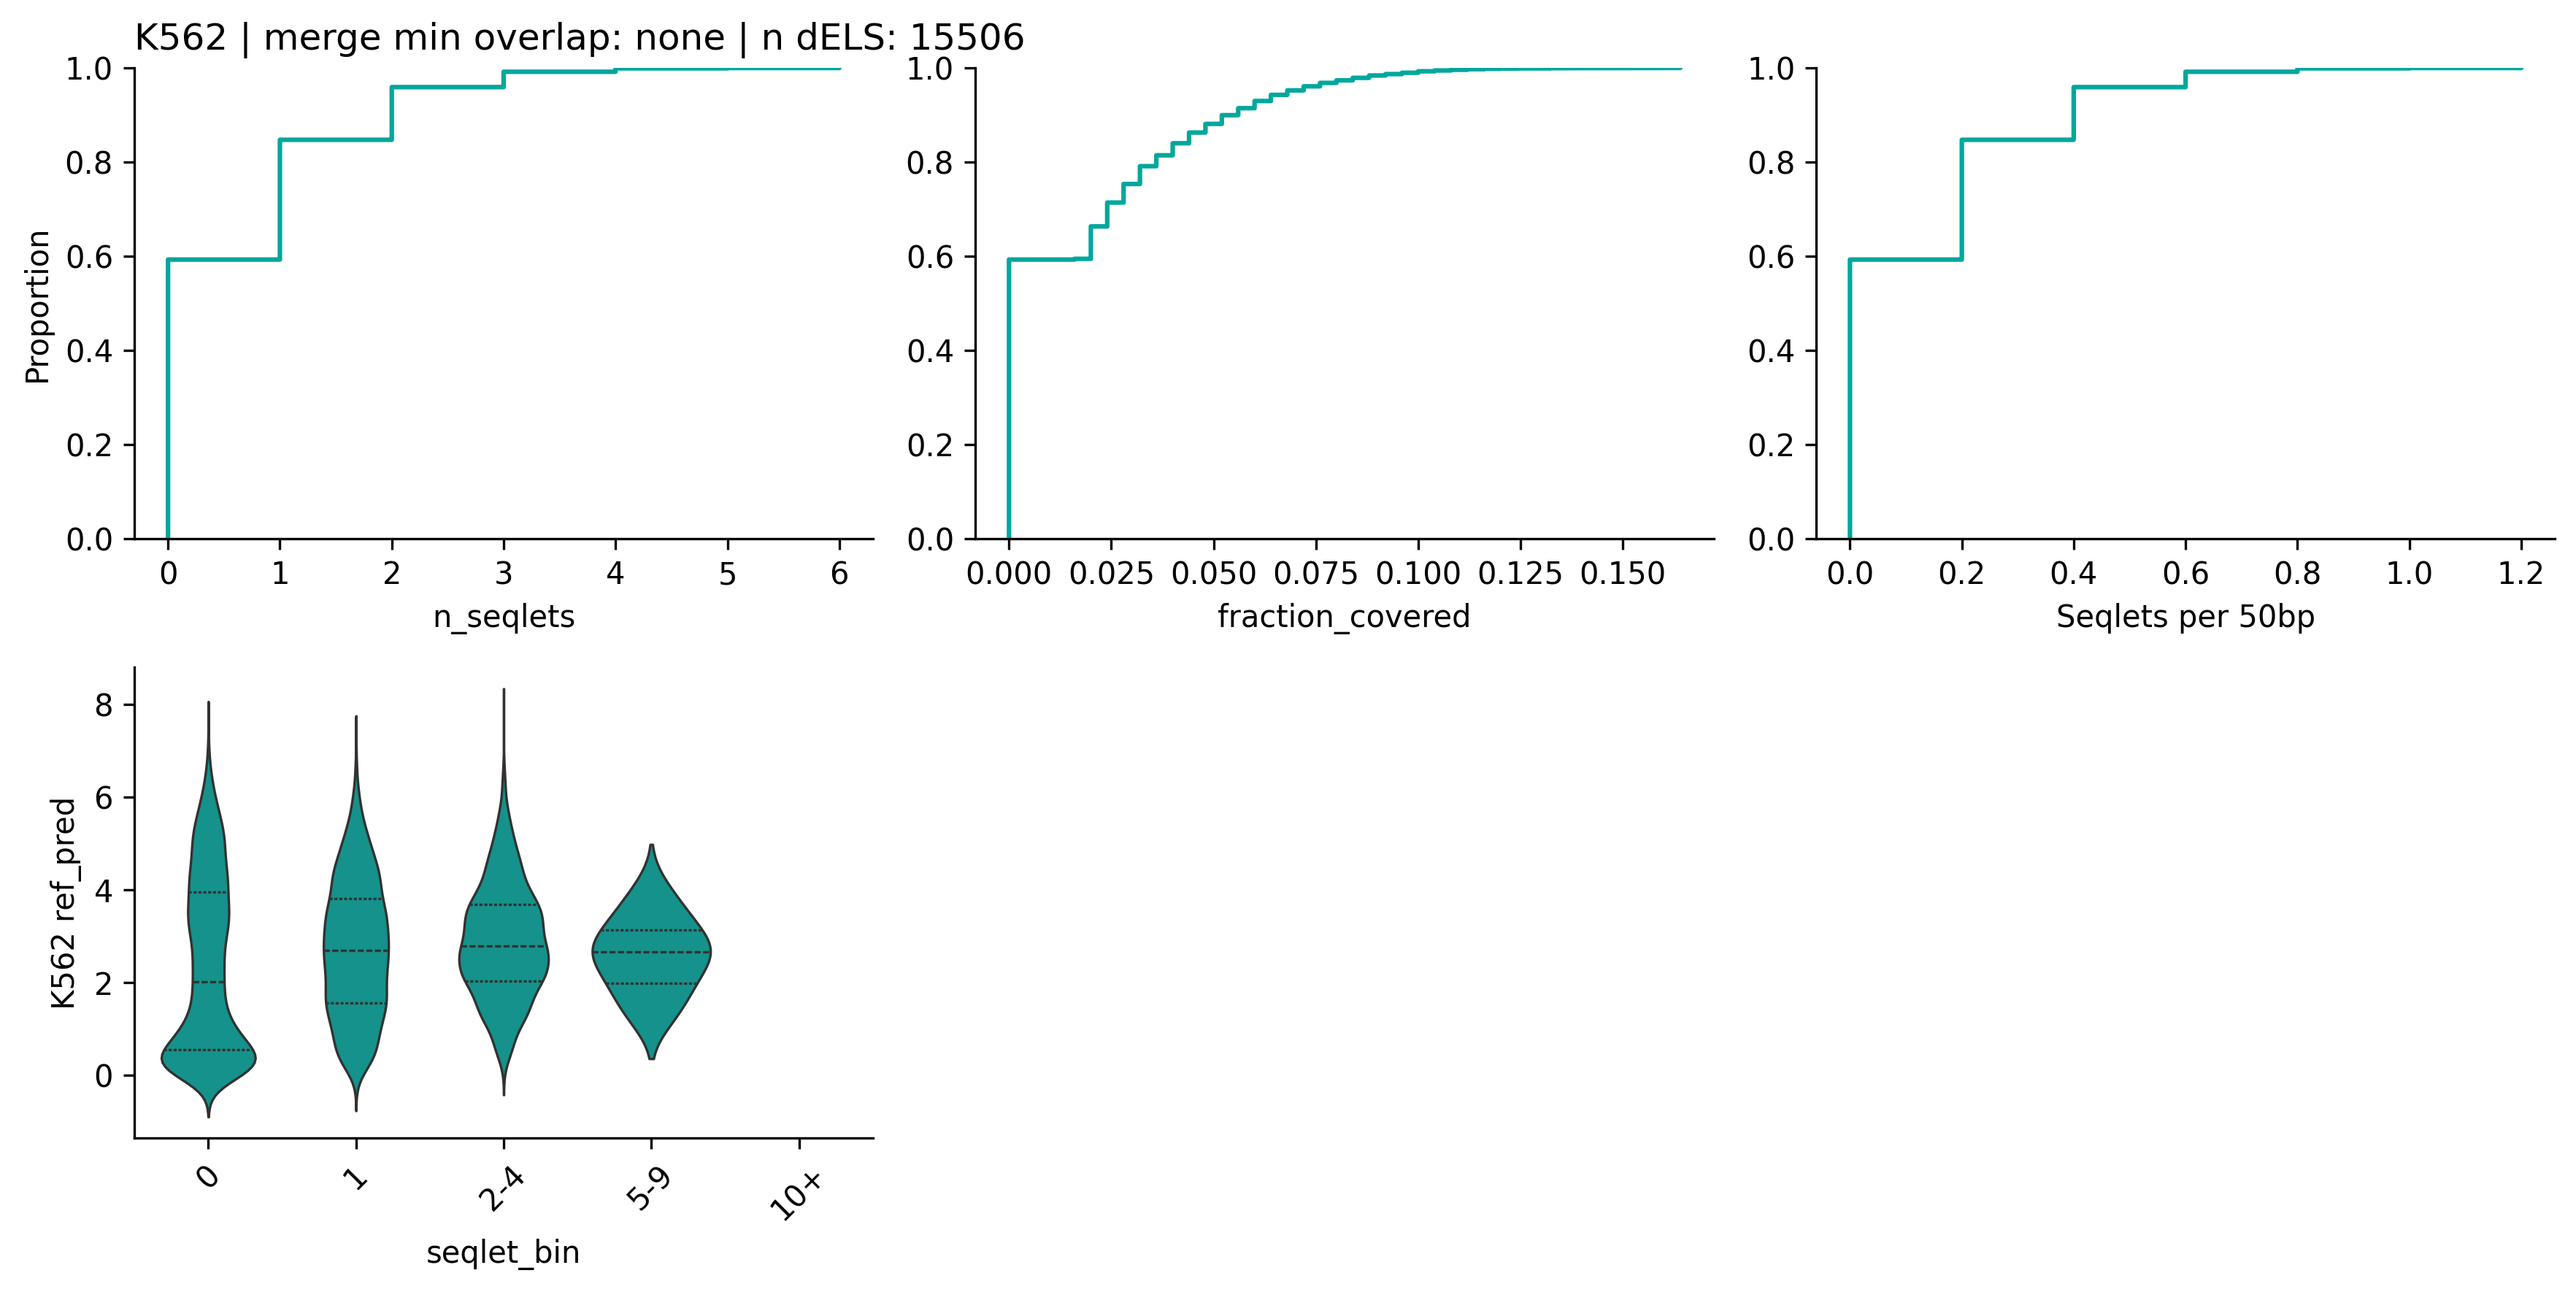

In [108]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/K562_01_Min2ovr_250bp_pro_cover.bed',
                            'k562',
                            all_tabix_mpac_mean,
                            'none')

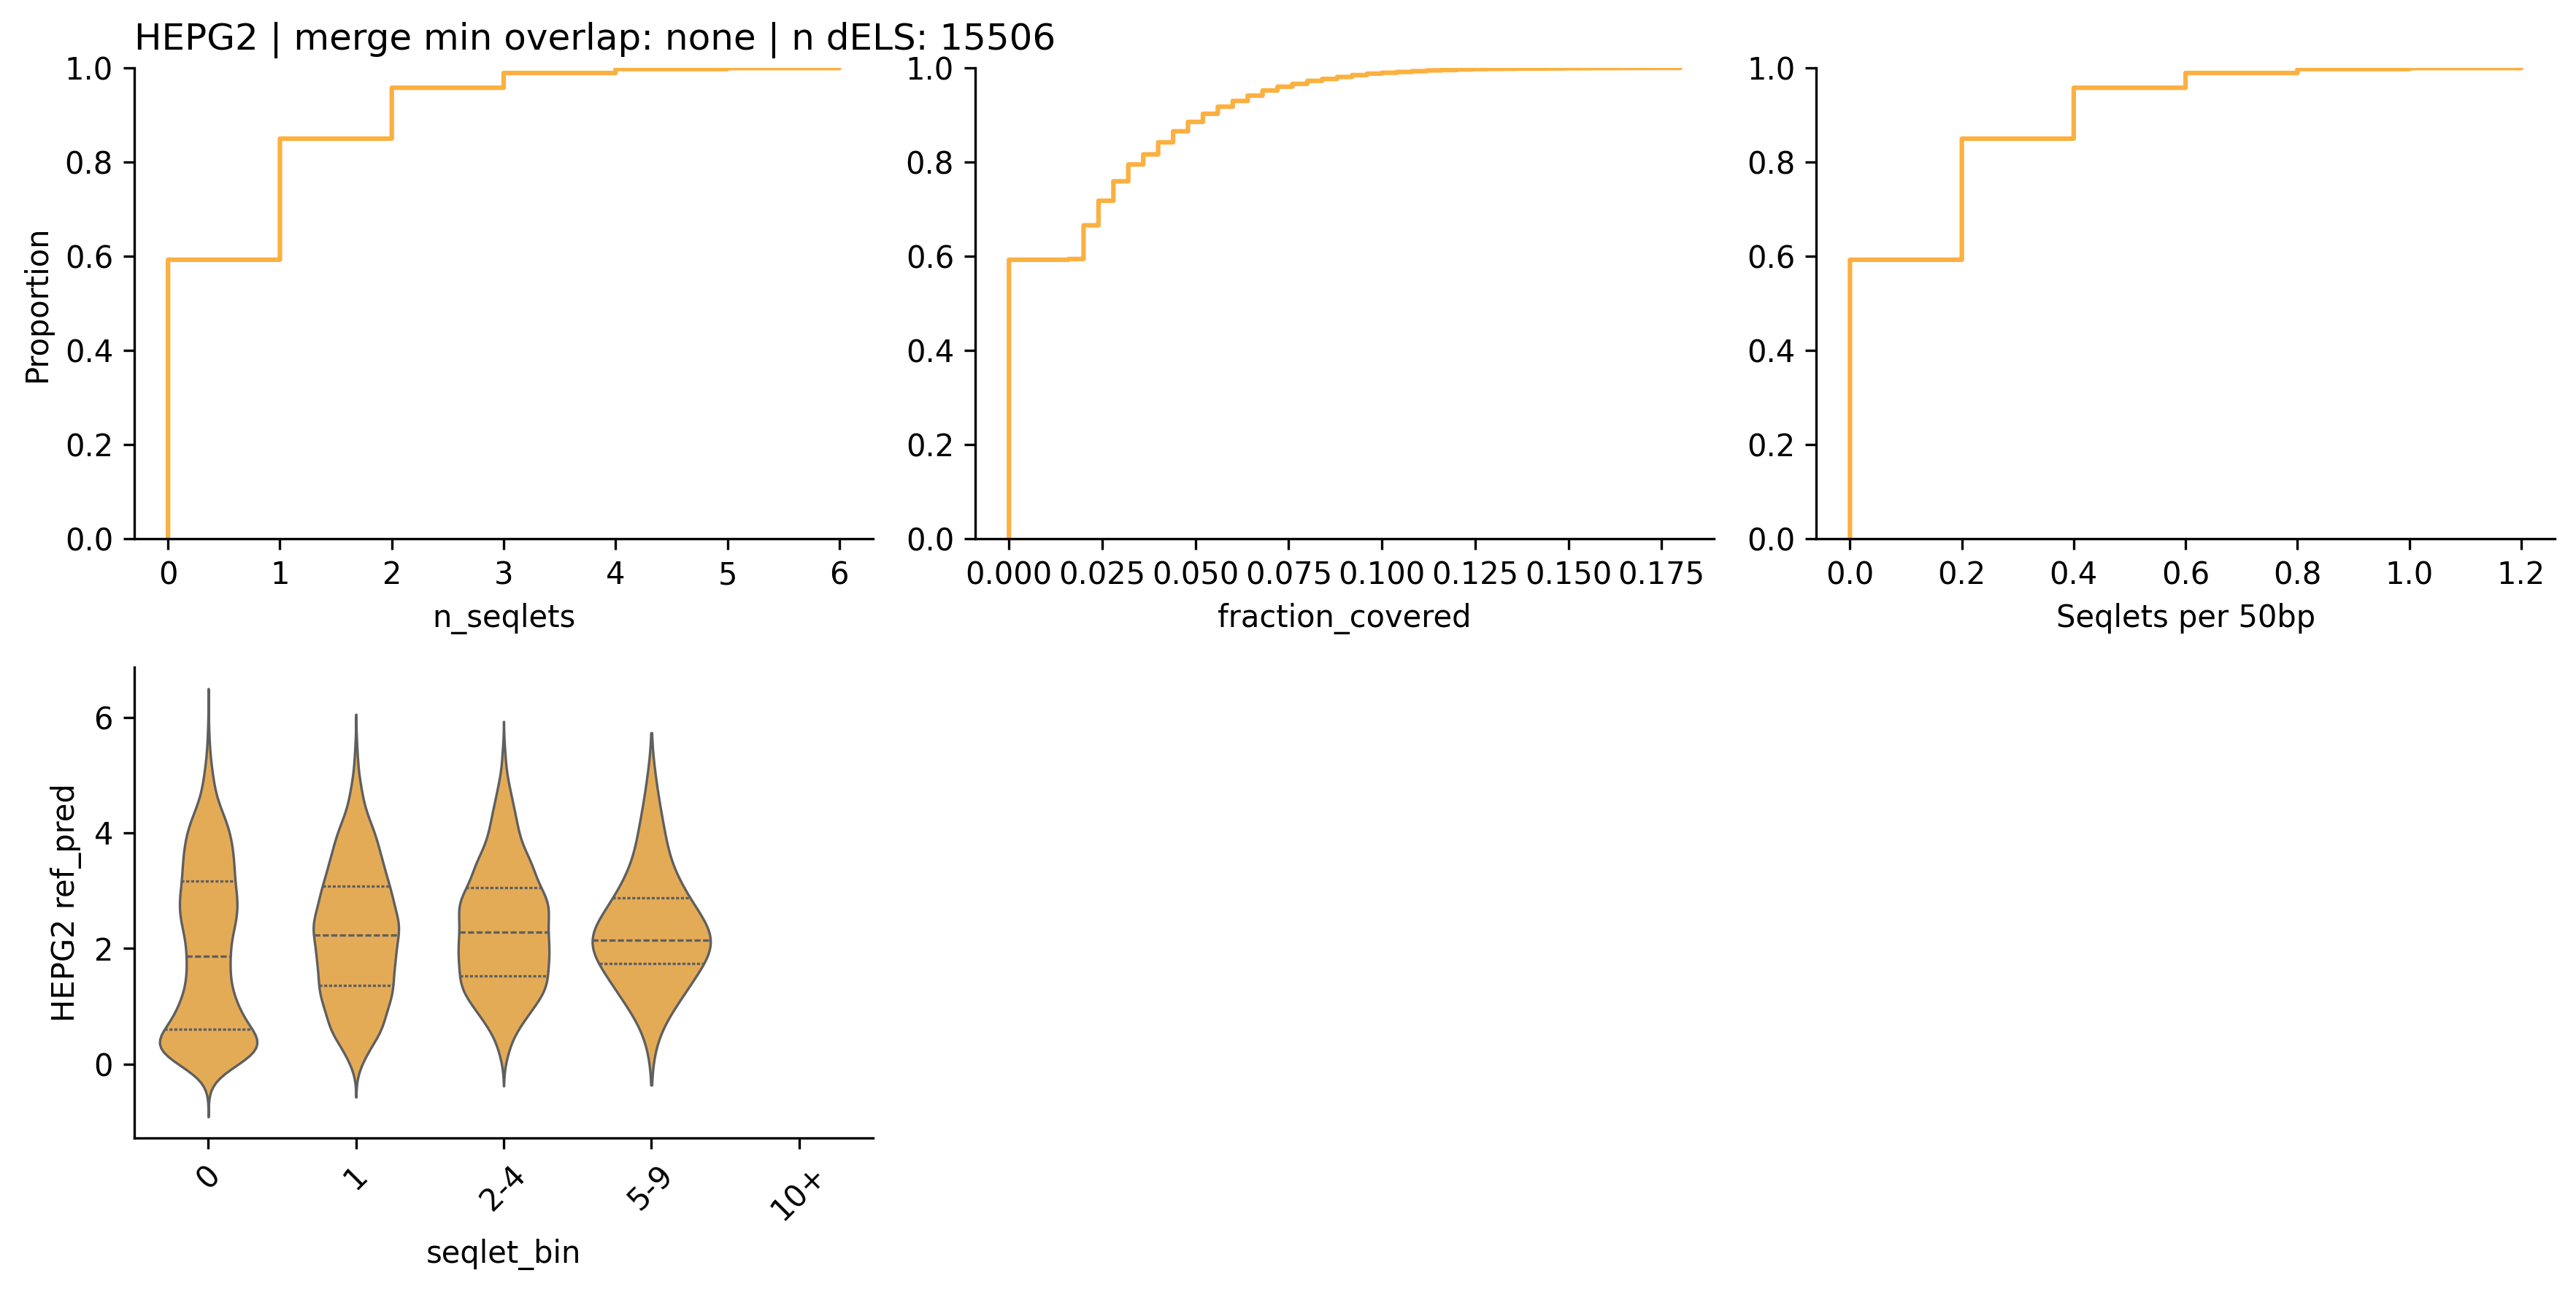

In [110]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/HepG2_01_Min2ovr_250bp_pro_cover.bed',
                            'hepg2',
                            all_tabix_mpac_mean,
                            'none')

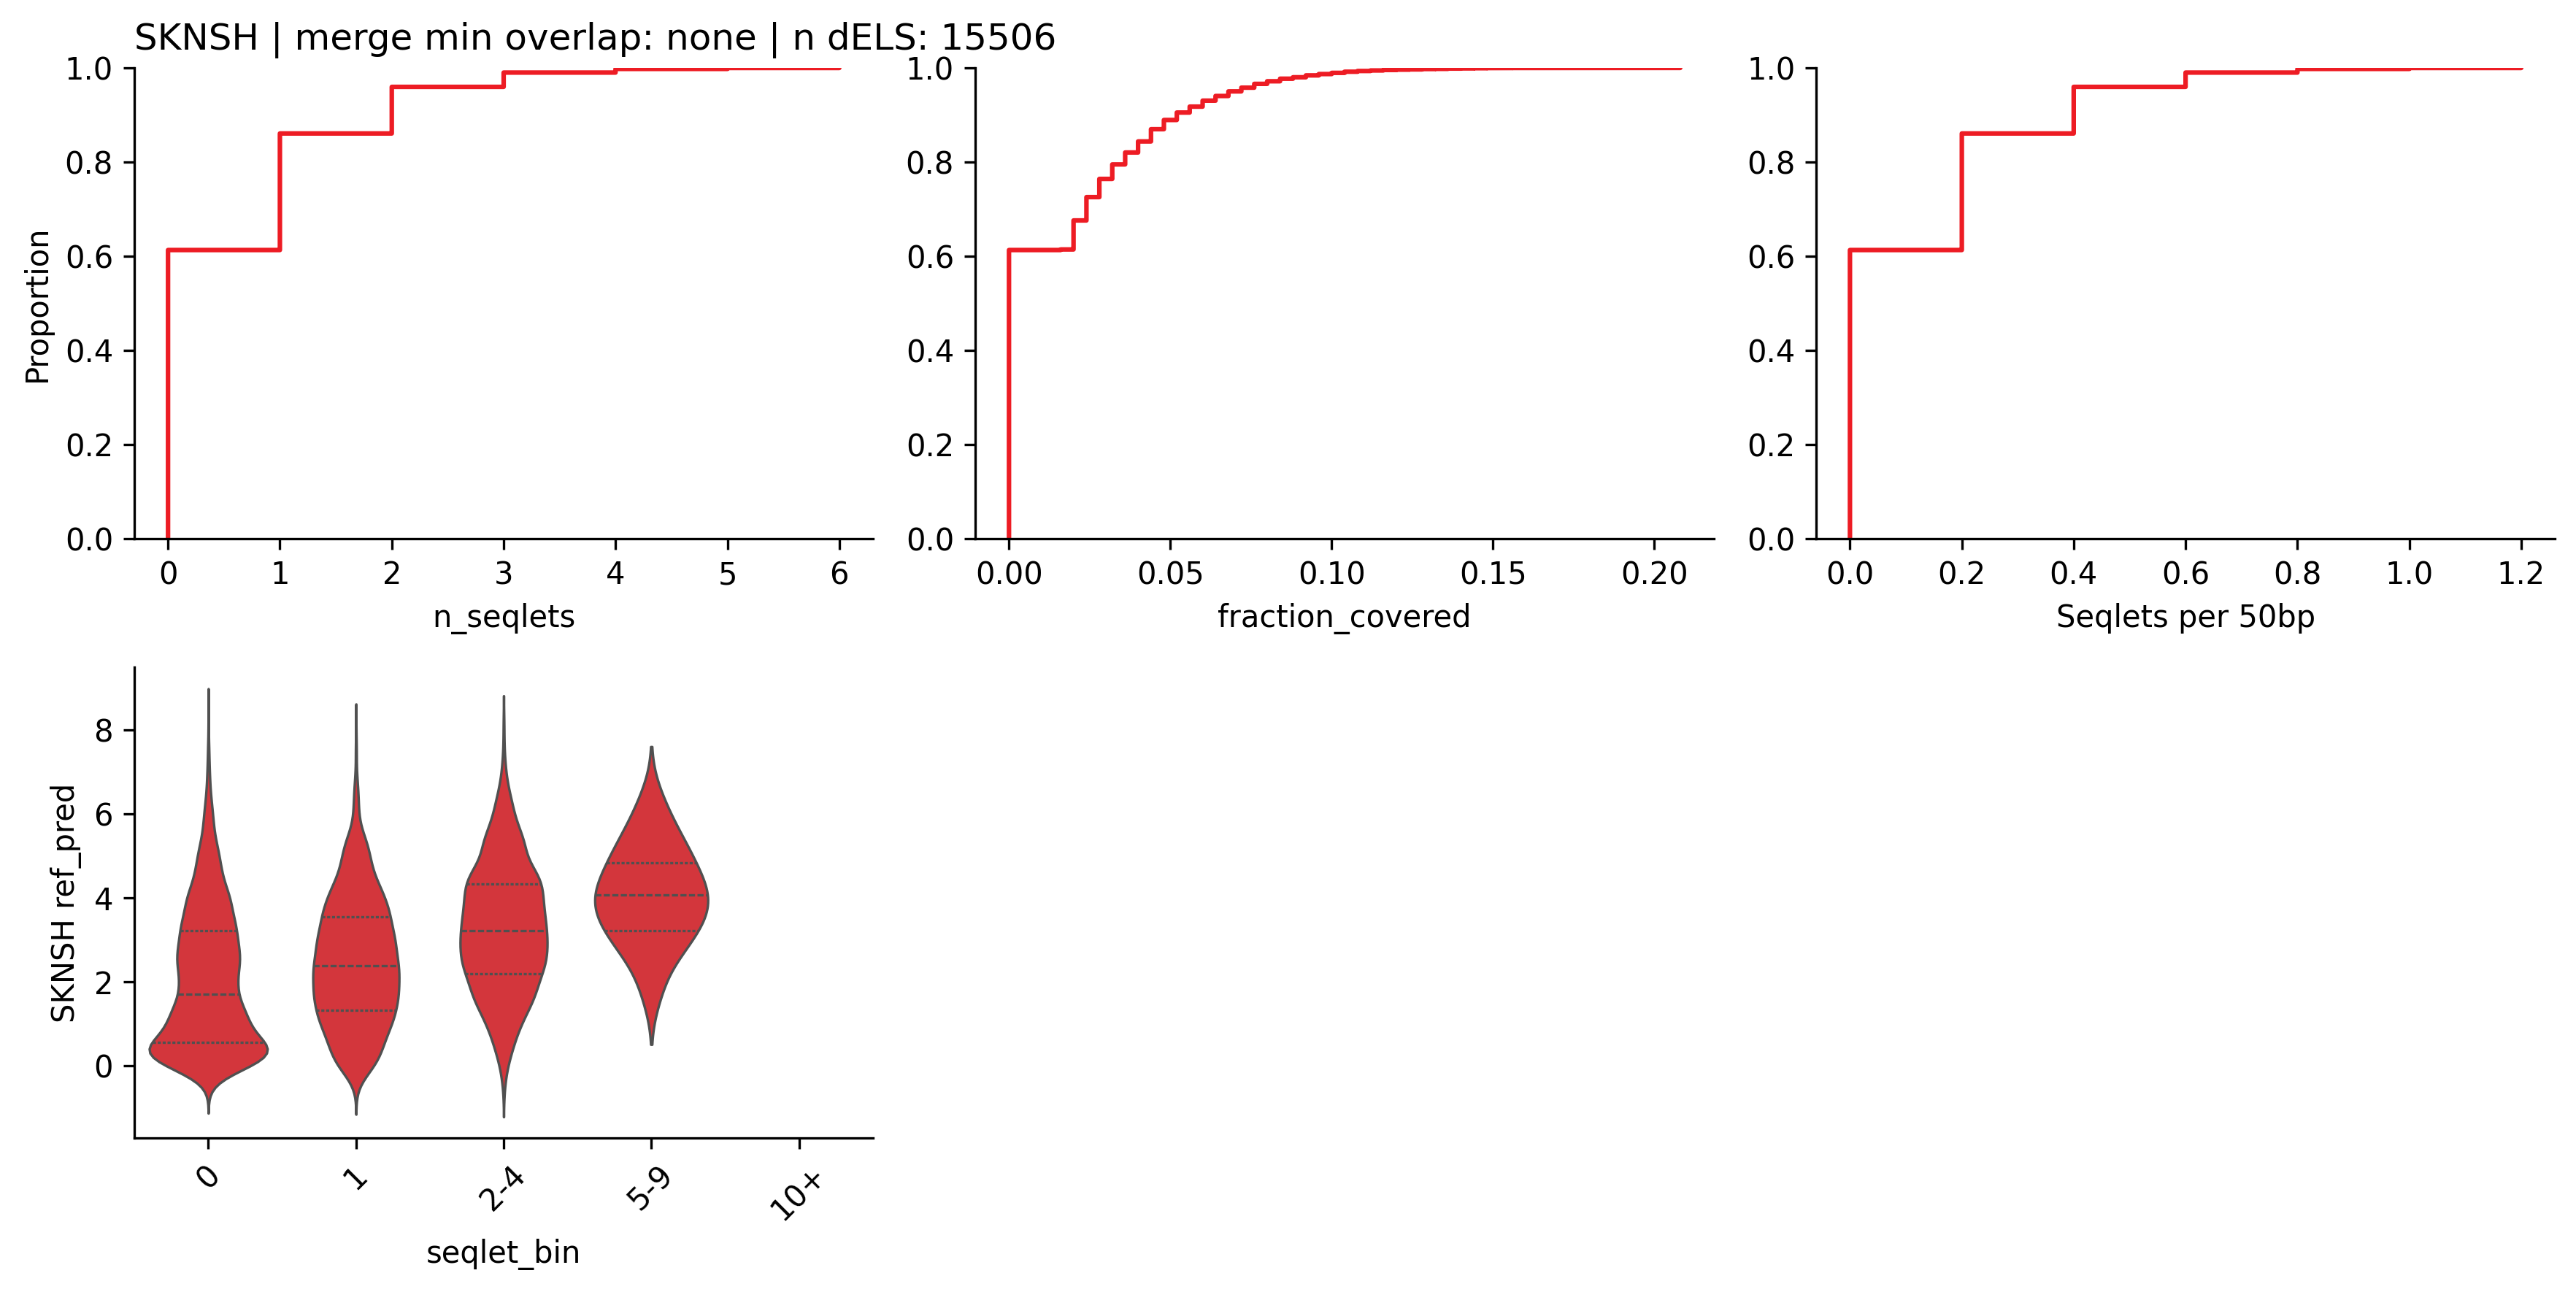

In [114]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/SKNSH_01_Min2ovr_250bp_pro_cover.bed',
                            'sknsh',
                            all_tabix_mpac_mean,
                            'none')

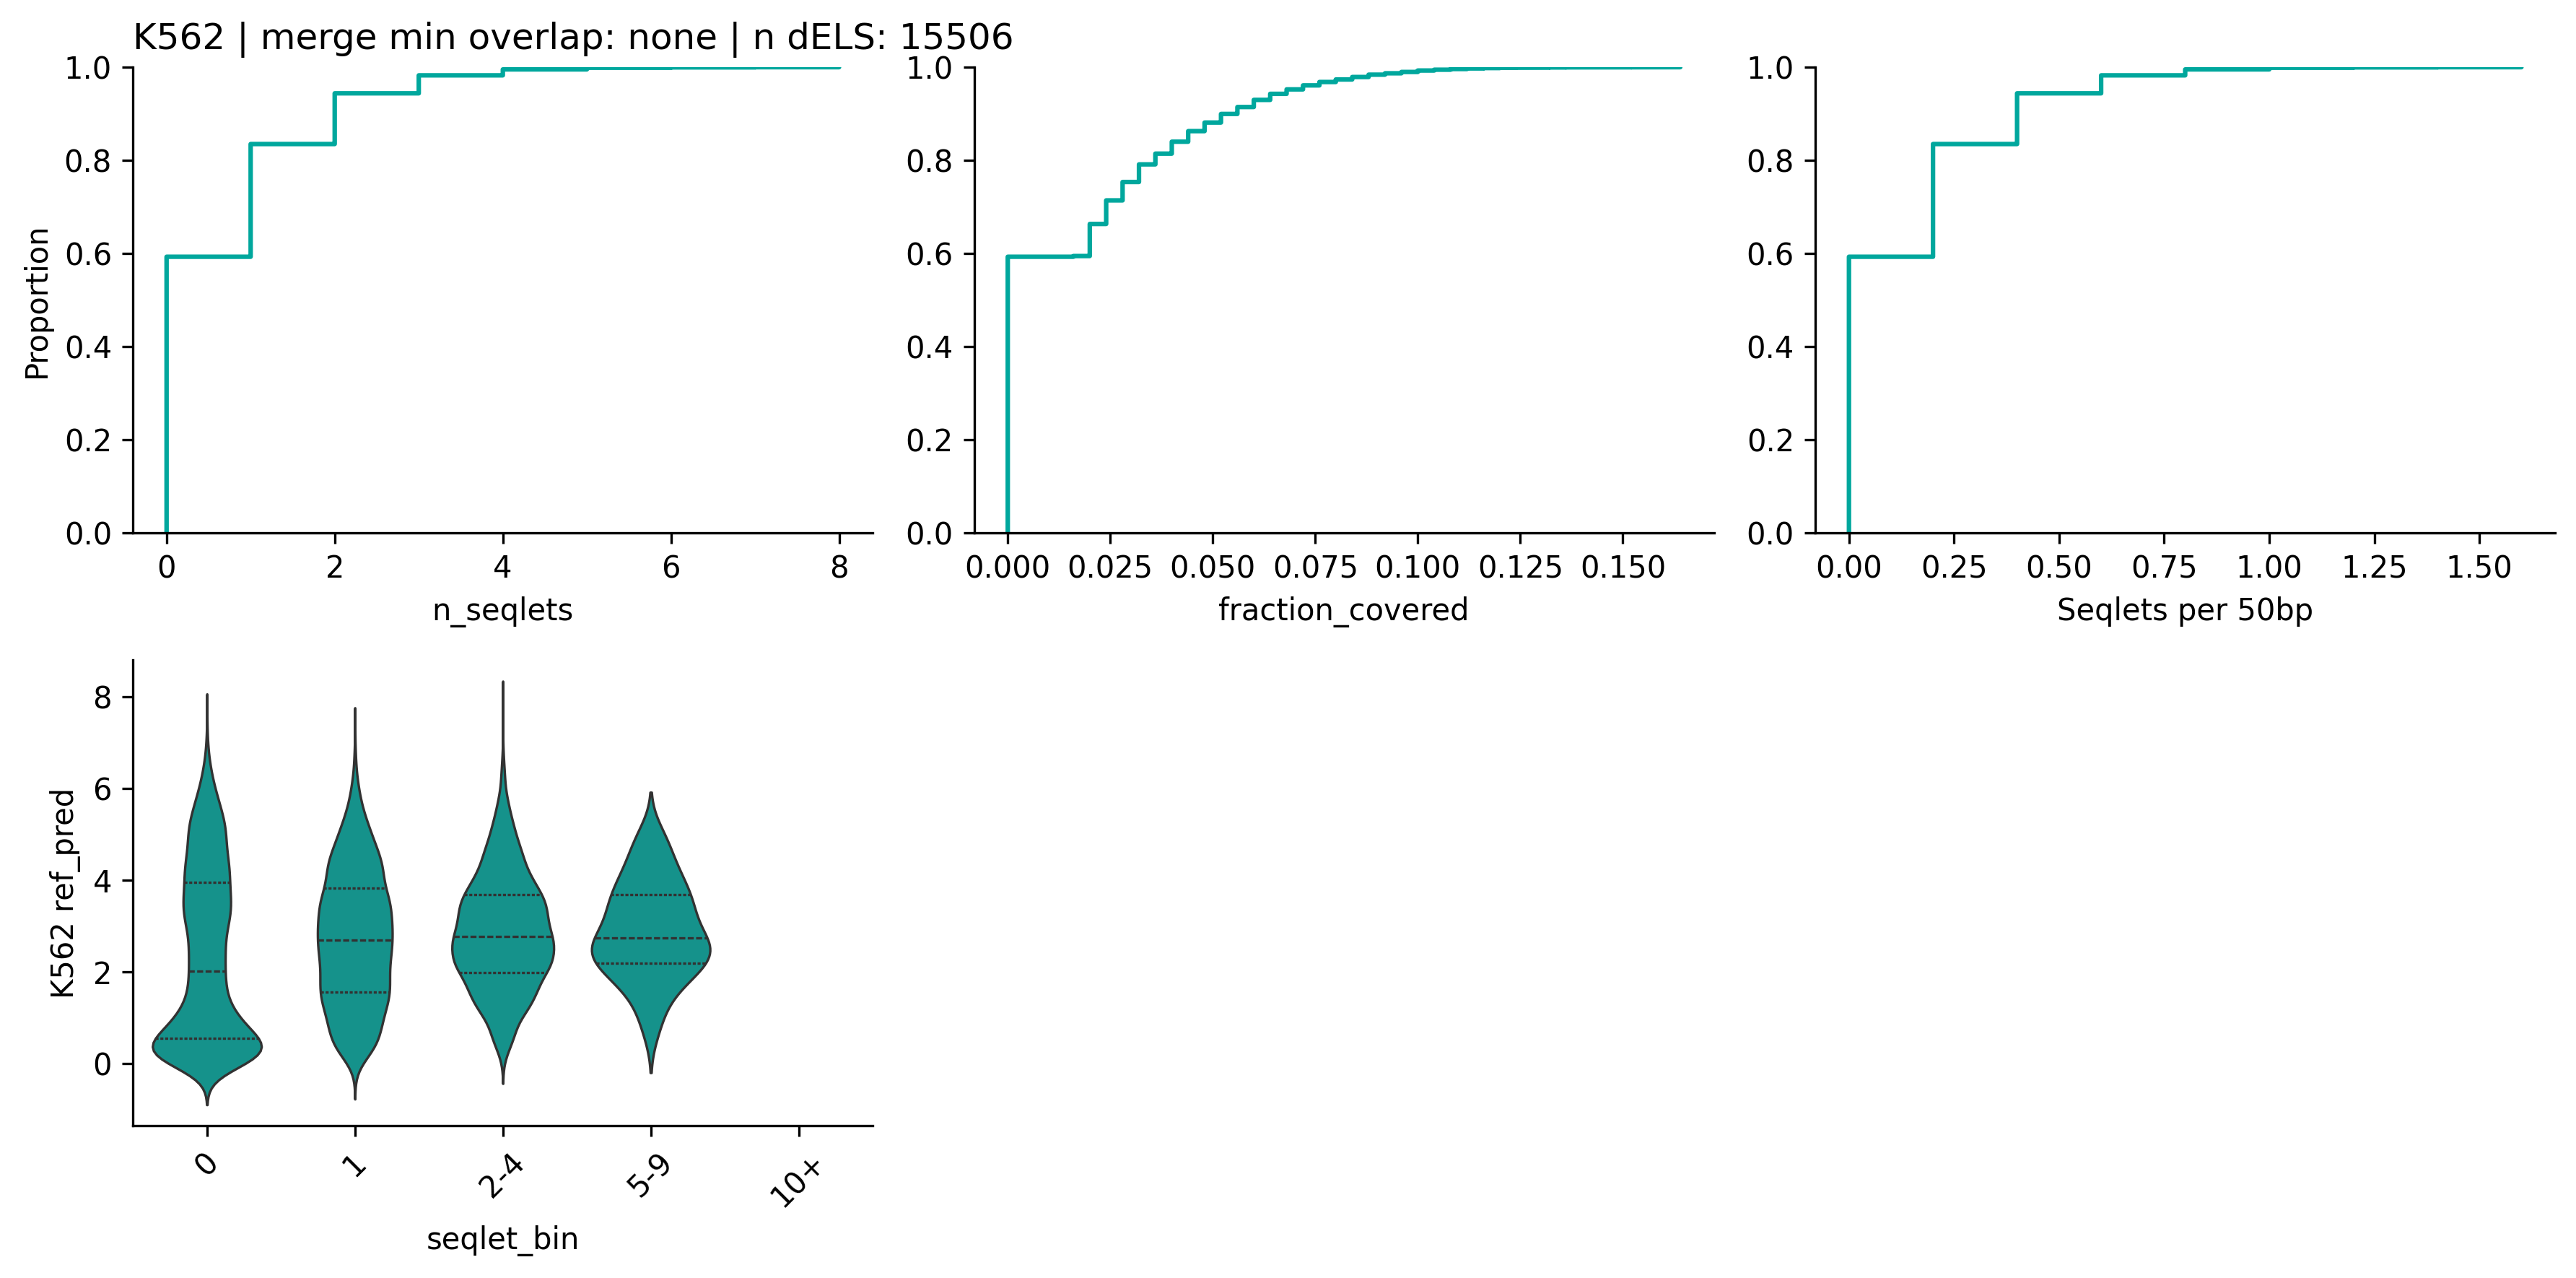

In [112]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/K562_01_Min4ovr_250bp_pro_cover.bed',
                            'k562',
                            all_tabix_mpac_mean,
                            'none')

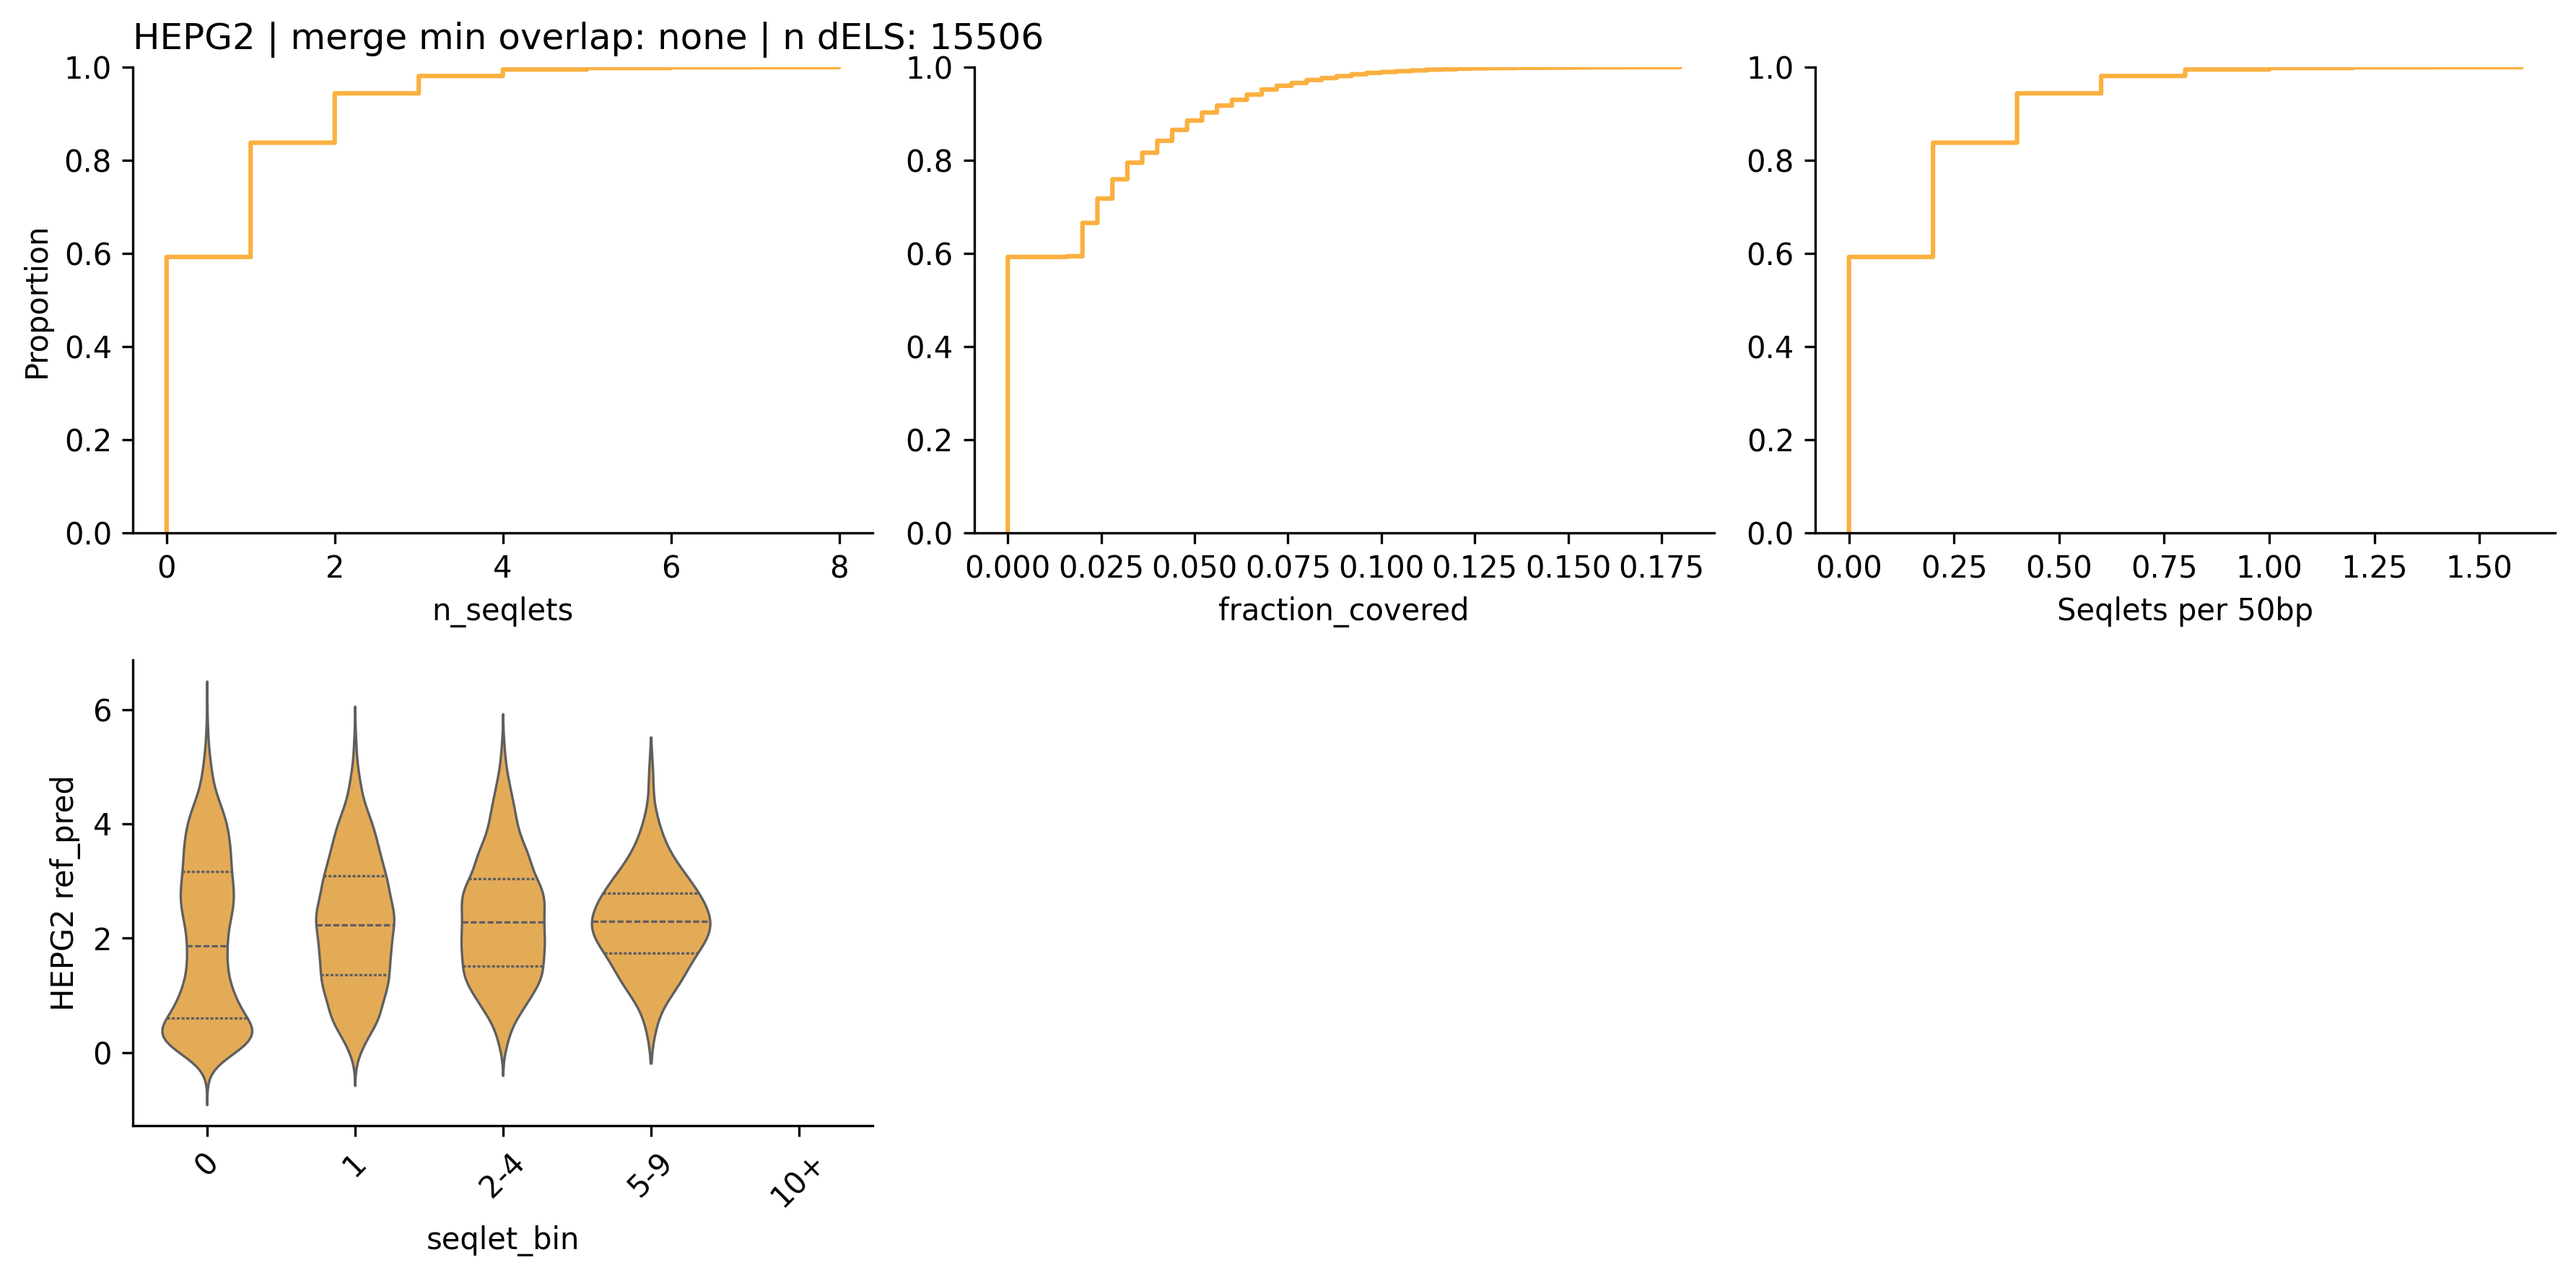

In [113]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/HepG2_01_Min4ovr_250bp_pro_cover.bed',
                            'hepg2',
                            all_tabix_mpac_mean,
                            'none')

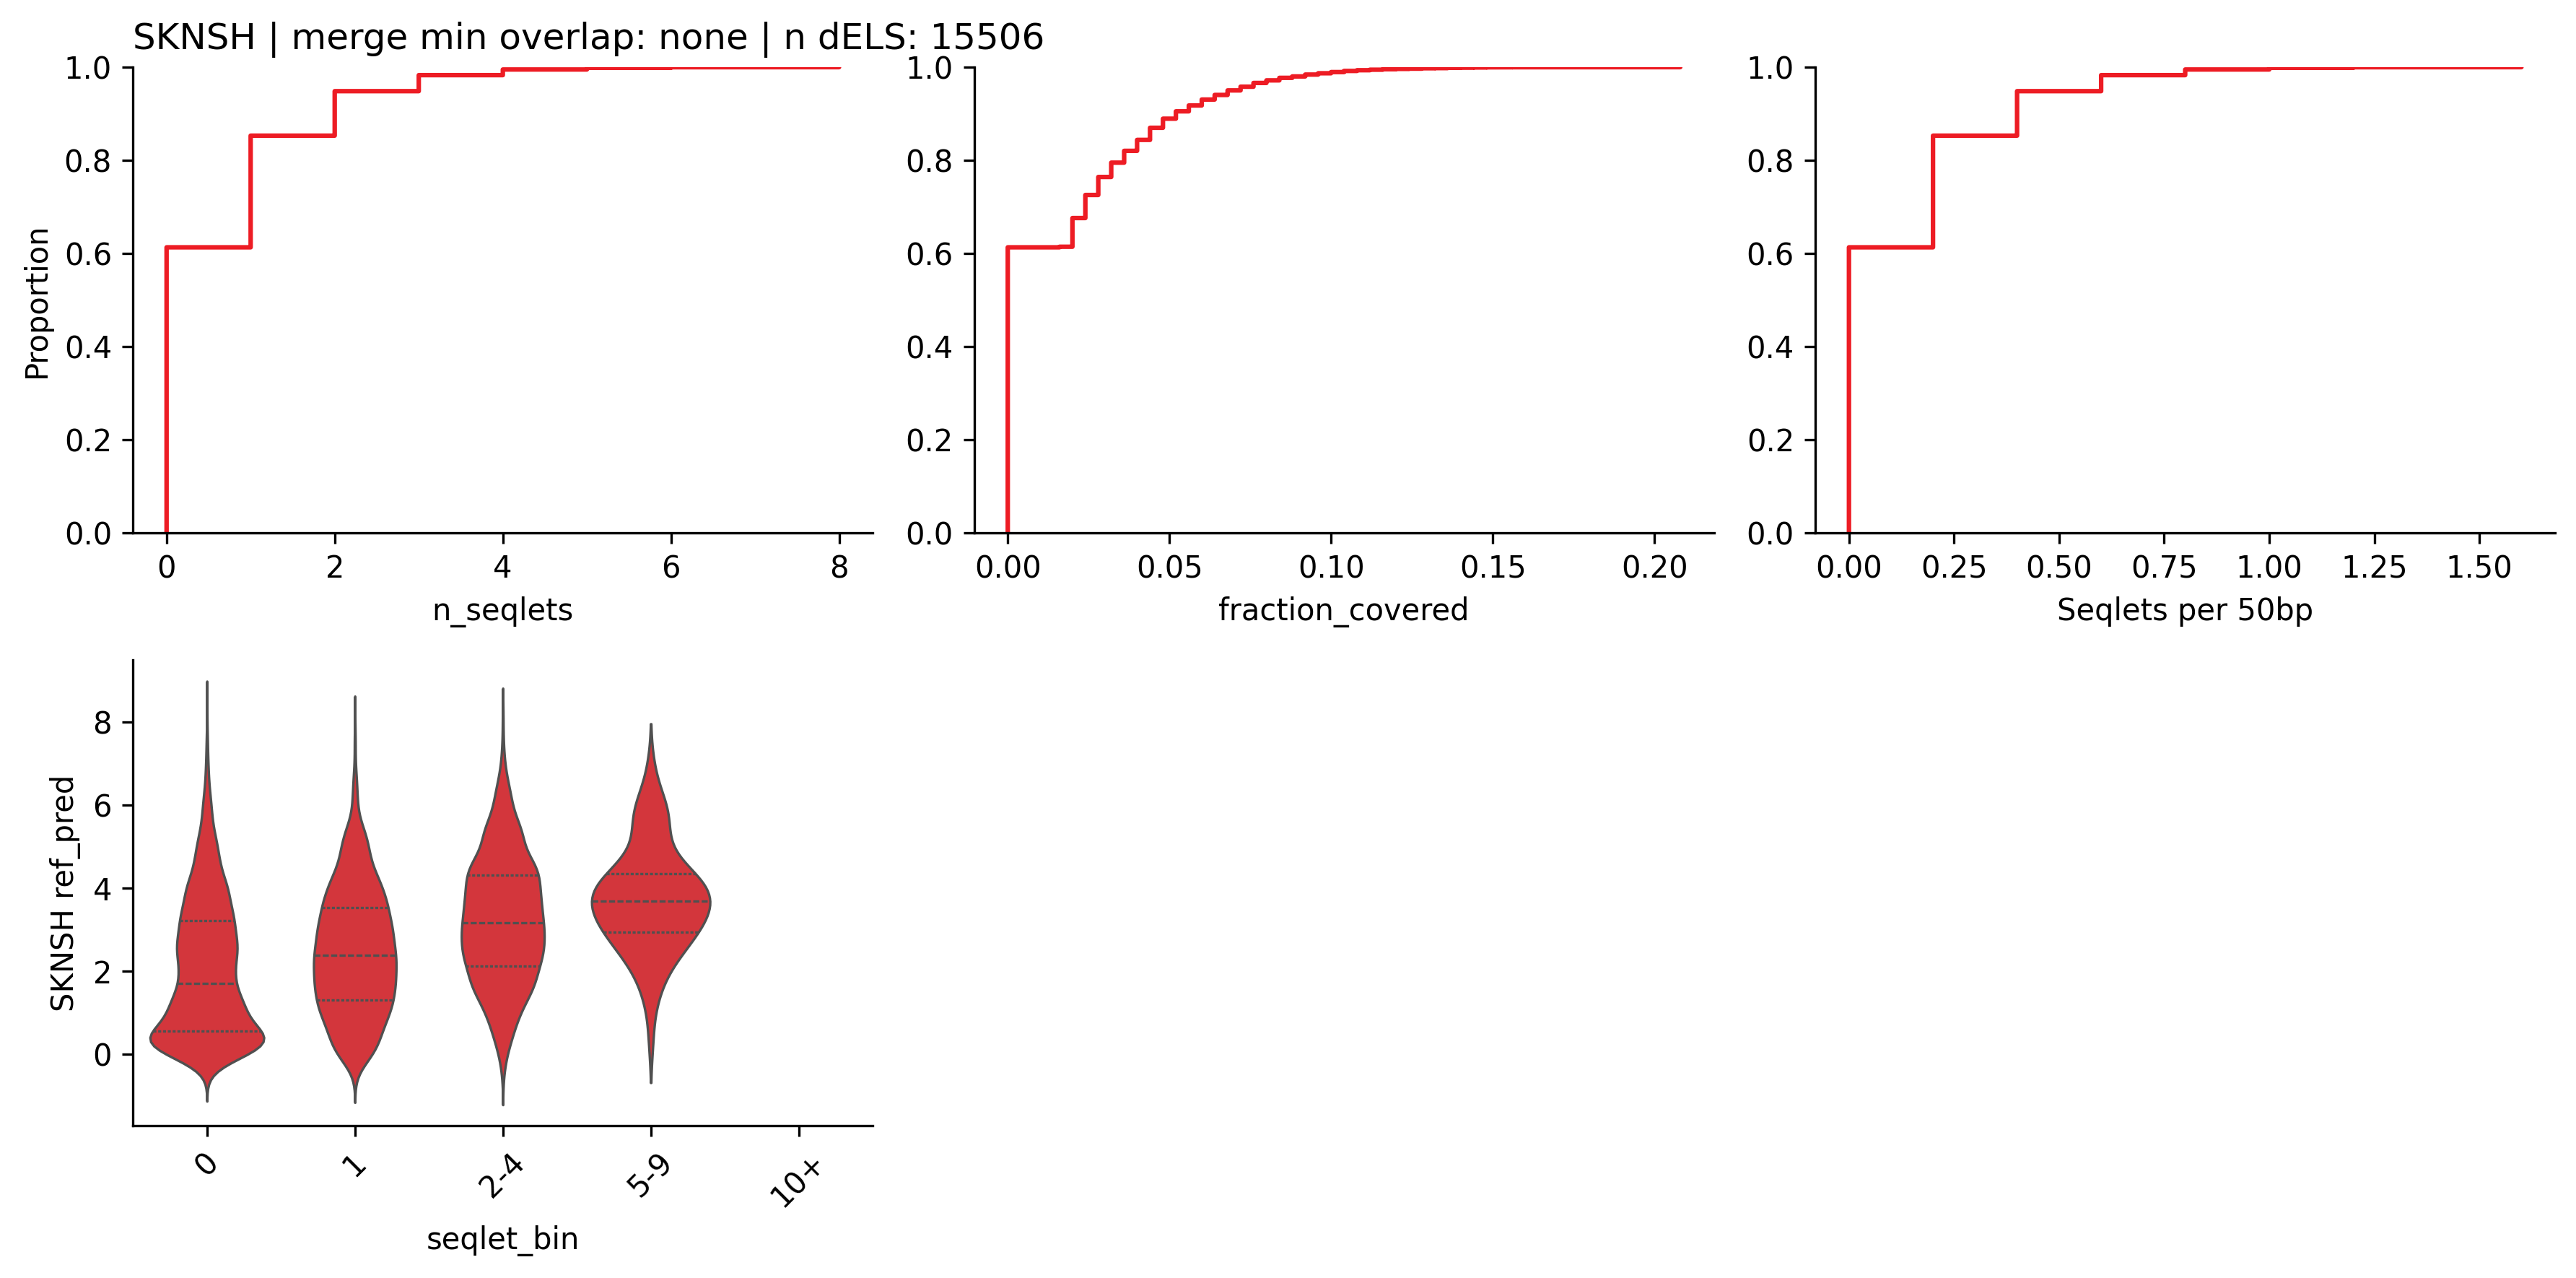

In [115]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/SKNSH_01_Min4ovr_250bp_pro_cover.bed',
                            'sknsh',
                            all_tabix_mpac_mean,
                            'none')